# **ENVIRONMENT SETUP**

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report
)

import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
tf.random.set_seed(42)

np.random.seed(42)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# **LOAD DATASET**

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **EXPLORATORY DATA ANALYSIS**

In [3]:
# Dataset Overview
summary = pd.Series({

    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Memory (MB)": round(df.memory_usage(deep=True).sum()/1024**2,2),
    "Missing values": df.isna().sum().sum(),
    "Duplicate rows": df.duplicated().sum()

})

display(summary.to_frame(name="Value"))

,Value
Rows,284807.00
Columns,31.00
Memory (MB),67.36
Missing values,0.00
Duplicate rows,1081.00


In [4]:
# Duplicate records
non_fraud_duplicates = df[df["Class"] == 0].duplicated().sum()
print(f"Count of Duplicates in Non Fraud Class = {non_fraud_duplicates}")

fraud_duplicates = df[df["Class"] == 1].duplicated().sum()
print(f"Count of Duplicates in Fraud Class = {fraud_duplicates}")

print(f"Total Number of Duplicates = {df.duplicated().sum()}")

Count of Duplicates in Non Fraud Class = 1062
Count of Duplicates in Fraud Class = 19
Total Number of Duplicates = 1081


In [5]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
# Random Sample
display(df.sample(5, random_state=42))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [8]:
# Target Variable Distribution
class_counts = (
    df["Class"]
    .value_counts()
    .rename(index={0: "Non-Fraud", 1: "Fraud"})
)

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={0: "Non-Fraud", 1: "Fraud"})
    .round(3)
)

target_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

display(target_summary)

,Count,Percentage (%)
Class,,
Non-Fraud,284315,99.827
Fraud,492,0.173


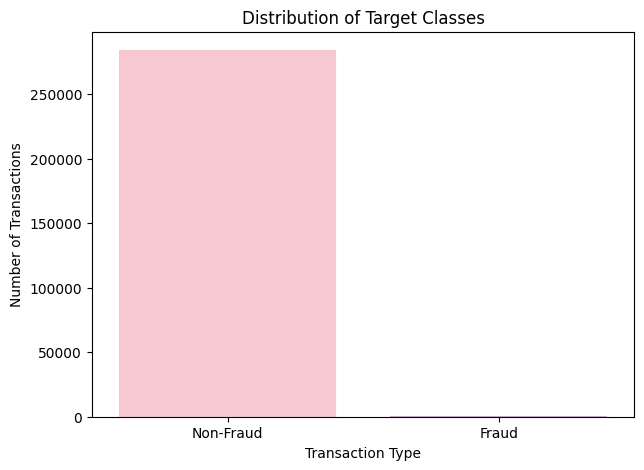

In [9]:
# Class Distribution
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette=["pink", "plum"],
    legend=False
)

ax.set_xticklabels(["Non-Fraud", "Fraud"])

plt.title("Distribution of Target Classes")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

### **Observation**
The dataset is extremely imbalanced.

Fraudulent transactions represent only a very small proportion of the entire dataset.

This imbalance should be considered during model development because accuracy alone would provide misleading performance estimates.

Therefore, model performance will primarily be evaluated using Precision, Recall, F1-score, ROC-AUC, and PR-AUC rather than Accuracy.

In [10]:
# Dataset Summary

class_counts = df["Class"].value_counts(normalize=True) * 100

dataset_summary = pd.DataFrame({
    "Check": [
        "Number of transactions",
        "Number of features",
        "Target variable",
        "Missing values",
        "Duplicate rows",
        "Data types",
        "Class imbalance"
    ],
    "Result": [
        f"{df.shape[0]:,}",
        df.shape[1] - 1,
        "Binary",
        "None" if df.isnull().sum().sum() == 0 else f"{df.isnull().sum().sum():,}",
        f"{df.duplicated().sum():,}",
        "Numeric",
        f"Non-Fraud: {class_counts.get(0, 0):.2f}% / "
        f"Fraud: {class_counts.get(1, 0):.2f}%"
    ]
})

dataset_summary.style \
    .hide(axis="index") \
    .set_caption("Dataset Summary") \
    .set_properties(**{
        "text-align": "left",
        "font-size": "12pt"
    })

Check,Result
Number of transactions,"284,807"
Number of features,30
Target variable,Binary
Missing values,None
Duplicate rows,"1,081"
Data types,Numeric
Class imbalance,Non-Fraud: 99.83% / Fraud: 0.17%


In [11]:
# Transaction Amount Summary
display(df["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

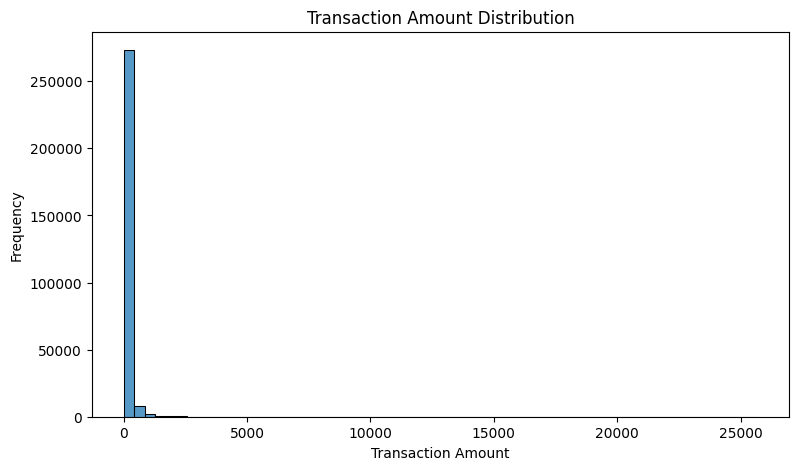

In [12]:
# Transaction Amount Distribution
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Amount",
    bins=60,
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

### **Observation**

The original transaction amounts are highly right-skewed due to the presence of a small number of exceptionally large transactions.

To better visualize the underlying distribution, a logarithmic transformation is applied only for **visualization purposes**. The original data remain unchanged and will be used during subsequent preprocessing and model training.

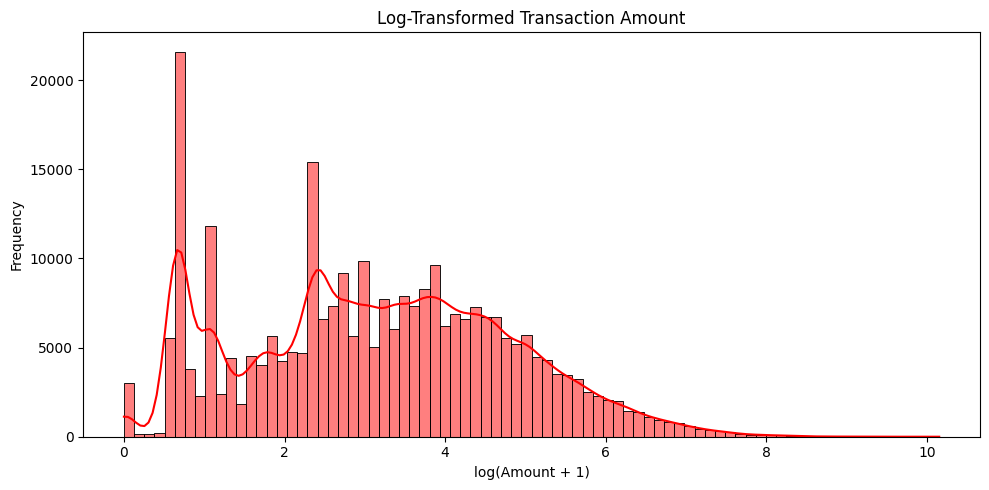

In [13]:
# Log-Transformed Transaction Amount

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=80,
    kde=True,
    color="red"
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### **Observation**

The logarithmic transformation reduces the influence of extreme transaction amounts and reveals the underlying shape of the distribution more clearly.

Although the distribution remains positively skewed, the majority of transactions become easier to examine, confirming that most operations involve relatively small monetary amounts.

In [14]:
# Transaction Time Summary
display(df["Time"].describe().to_frame(name="Time"))

,Time
count,284807.000000
mean,94813.859575
std,47488.145955
min,0.000000
25%,54201.500000
50%,84692.000000
75%,139320.500000
max,172792.000000


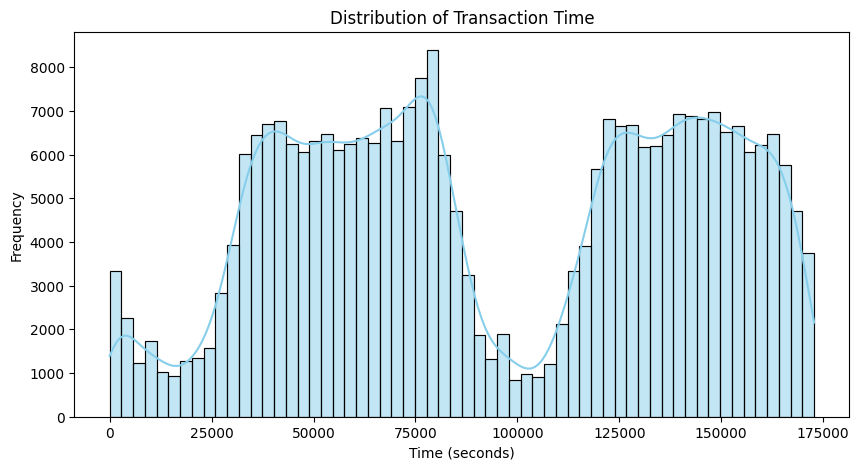

In [15]:
# Distribution of Transaction Time
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Time",
    bins=60,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

### **Observation**

The histogram shows that transaction activity is not uniformly distributed over time. Instead, the data exhibit repeating activity cycles, indicating periods of higher and lower transaction frequency. Since the dataset spans approximately 48 hours, these fluctuations most likely correspond to normal daily patterns in customer activity rather than anomalies.

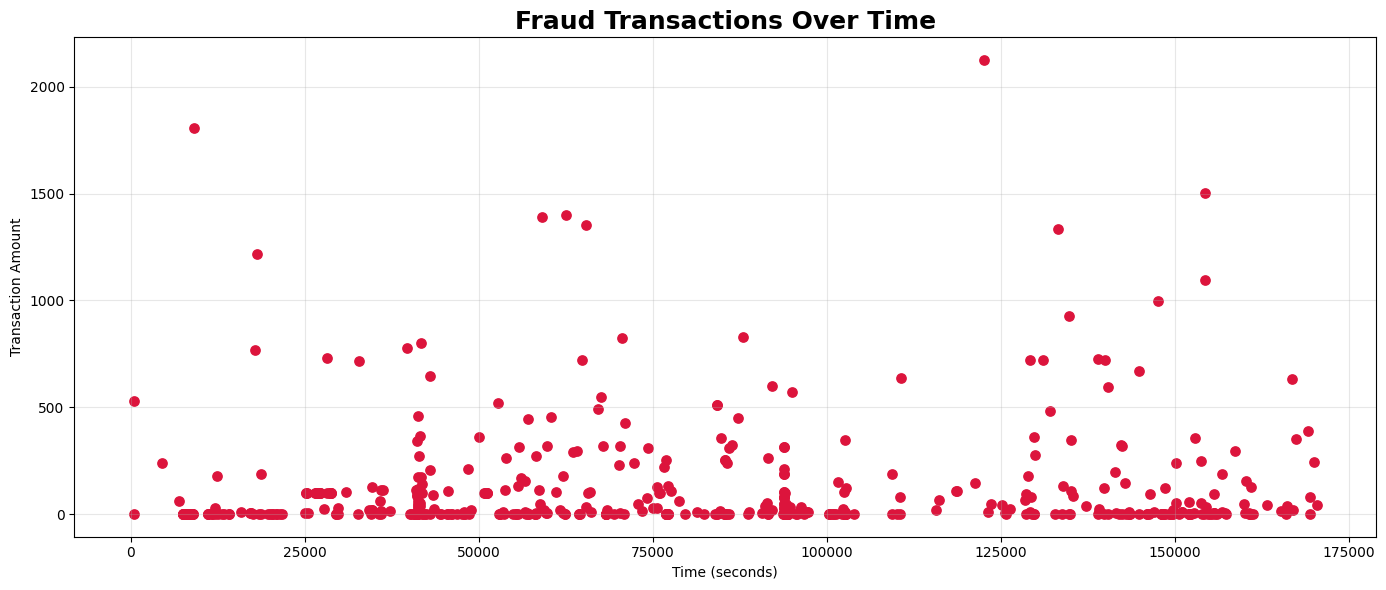

In [16]:
fraud = df[df["Class"] == 1]

plt.figure(figsize=(14,6))

plt.scatter(
    fraud["Time"],
    fraud["Amount"],
    color="crimson",
    s=45
)

plt.title("Fraud Transactions Over Time",
          fontsize=18,
          weight="bold")

plt.xlabel("Time (seconds)")
plt.ylabel("Transaction Amount")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **Observation**

Fraudulent transactions are observed throughout the entire observation period rather than being concentrated within a specific time interval.

Most fraud transactions involve relatively small amounts, while only a few exceed one thousand monetary units. No obvious temporal trend or clustering is visible, suggesting that fraudulent activities occur continuously over time.

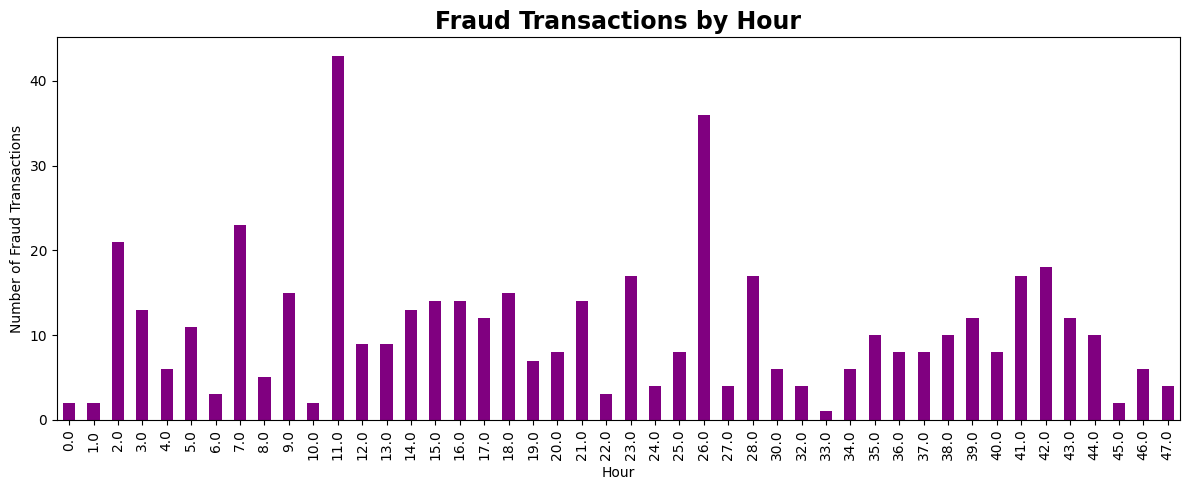

In [17]:
fraud = df[df["Class"] == 1].copy()

fraud["Hour"] = fraud["Time"] // 3600

fraud_per_hour = fraud.groupby("Hour").size()

plt.figure(figsize=(12,5))

fraud_per_hour.plot(kind="bar", color="purple")

plt.title("Fraud Transactions by Hour",
          fontsize=17,
          weight="bold")

plt.xlabel("Hour")
plt.ylabel("Number of Fraud Transactions")

plt.tight_layout()
plt.show()

### **Observation**

The number of fraud transactions varies across different hours of the observation period. Several hours contain noticeably more fraudulent transactions than others; however, fraud is present throughout nearly the entire dataset.

Overall, no single time period completely dominates fraudulent activity. Therefore, the Time feature alone is unlikely to provide strong predictive power for fraud detection, although it may still contribute useful information when combined with other variables.

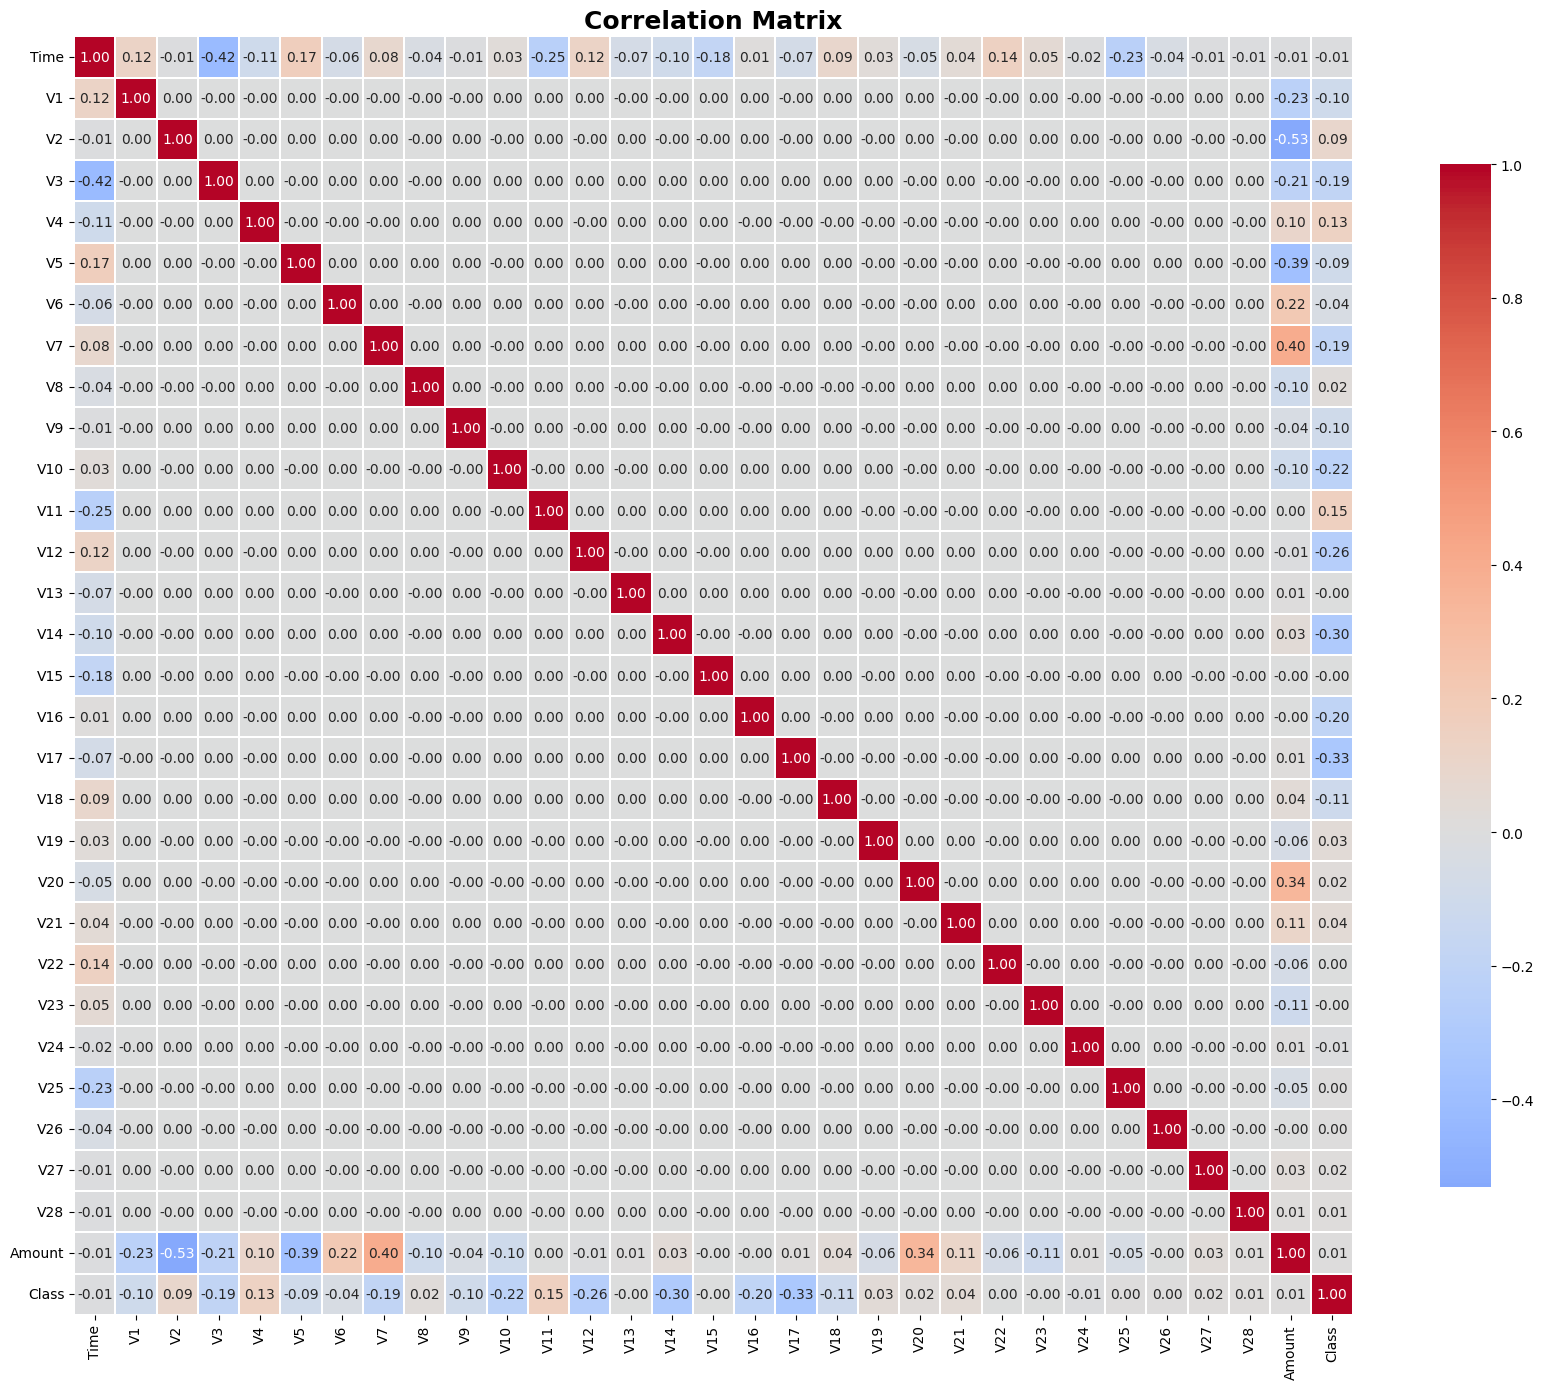

In [18]:
# Correlation Matrix
correlation_matrix = df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix", fontsize=18, weight="bold")

plt.tight_layout()

plt.show()

### **Observation**
The correlation matrix provides an overview of the linear relationships between all variables in the dataset.

Most feature pairs exhibit weak correlations, indicating that the anonymized PCA components capture largely independent sources of variation. This is expected because principal component analysis is specifically designed to produce uncorrelated features.

Consequently, severe multicollinearity is not expected to be a major concern for subsequent machine learning models.

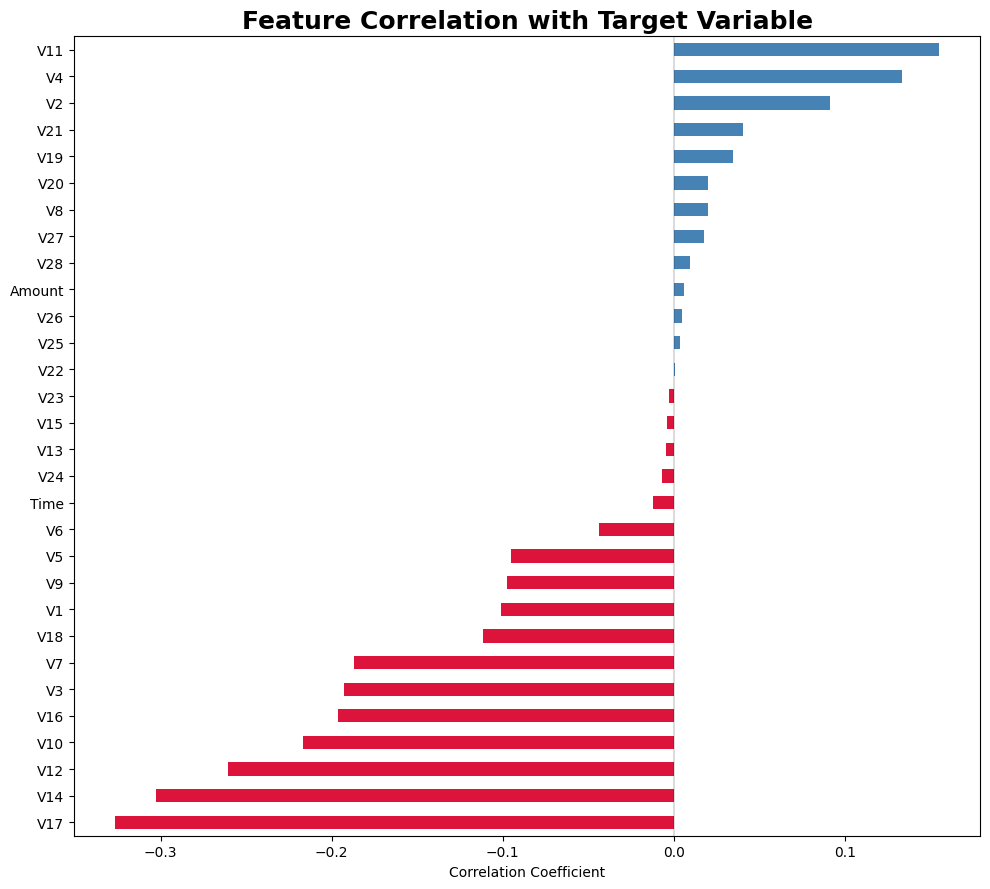

In [19]:
# Correlation with Target Variable

target_corr = (
    df.corr()["Class"]
    .drop("Class")
    .sort_values()
)

colors = [
    "crimson" if value < 0
    else "gray" if value == 0
    else "steelblue"
    for value in target_corr
]

plt.figure(figsize=(10, 9))

target_corr.plot(
    kind="barh",
    color=colors
)

plt.axvline(0, color="black", linewidth=0.2)

plt.title("Feature Correlation with Target Variable", fontsize=18, weight="bold")
plt.xlabel("Correlation Coefficient")

plt.tight_layout()
plt.show()

### **Observation**
The correlation coefficients indicate the strength and direction of the linear relationship between each feature and the target variable.

Several anonymized PCA components exhibit noticeably stronger correlations with the target class than the remaining variables. These features are expected to contribute more substantially to fraud detection models, whereas features with correlations close to zero are likely to provide limited predictive information when considered individually.

In [20]:
# Top Features Correlated with the Target Variable

target_corr = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values()
)

top_positive = target_corr.tail(10).sort_values(ascending=False)
top_negative = target_corr.head(10)

display(
    pd.DataFrame({
        "Top Positive Correlations": top_positive
    })
)

display(
    pd.DataFrame({
        "Top Negative Correlations": top_negative
    })
)

,Top Positive Correlations
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536
Amount,0.005632


,Top Negative Correlations
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


### **Observation**
The strongest positive and negative correlations provide an initial indication of which features may be most informative for fraud detection.

Although correlation alone does not imply predictive importance, variables exhibiting stronger relationships with the target are likely to contribute more effectively during model training.

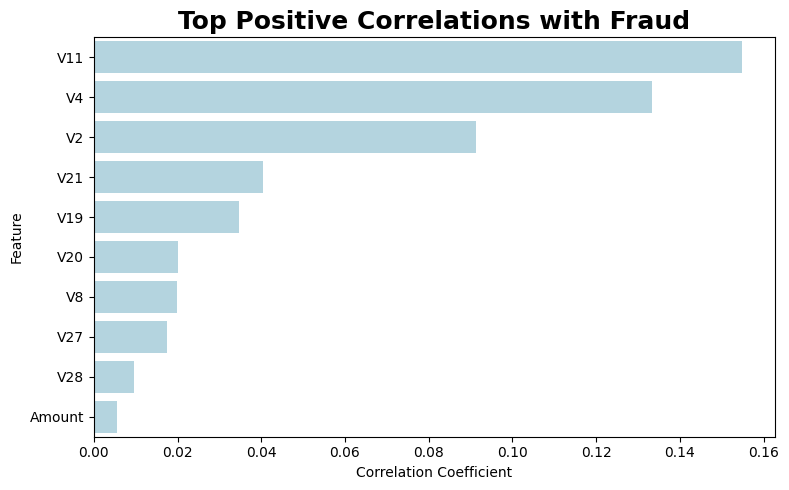

In [21]:
# Top Positive Correlations
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index,
    color="lightblue"
)

plt.title("Top Positive Correlations with Fraud", fontsize=18, weight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

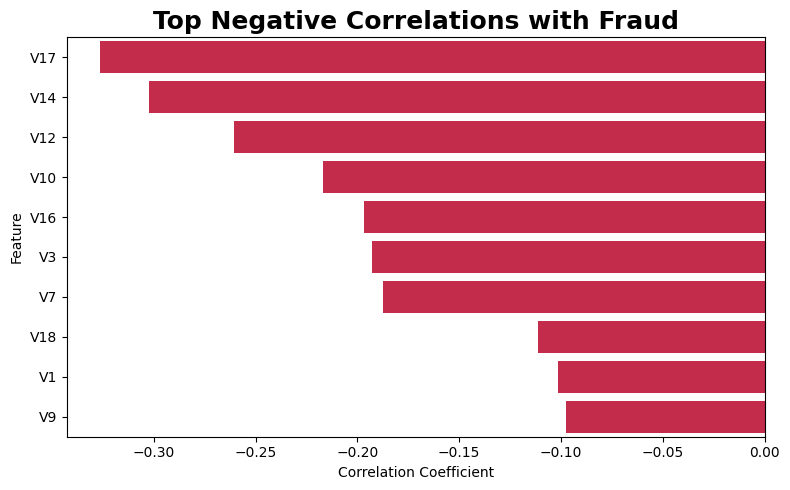

In [22]:
# Top Negative Correlations
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index,
    color="crimson"
)

plt.title("Top Negative Correlations with Fraud", fontsize=18, weight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### **Observation**

Several features exhibit relatively strong negative correlations with fraudulent transactions.

Lower values of these variables appear to be associated with fraud more frequently than with legitimate transactions. These features may therefore provide complementary information for distinguishing between the two classes.

In [23]:
# Select the Most Informative Features
# Absolute correlation with the target variable
feature_corr = (
    df.corr(numeric_only=True)["Class"]
      .drop("Class")
      .abs()
      .sort_values(ascending=False)
)

# Select the top 8 most informative features
top_features = feature_corr.head(8).index.tolist()

print("Top features:")
print(top_features)

Top features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11']


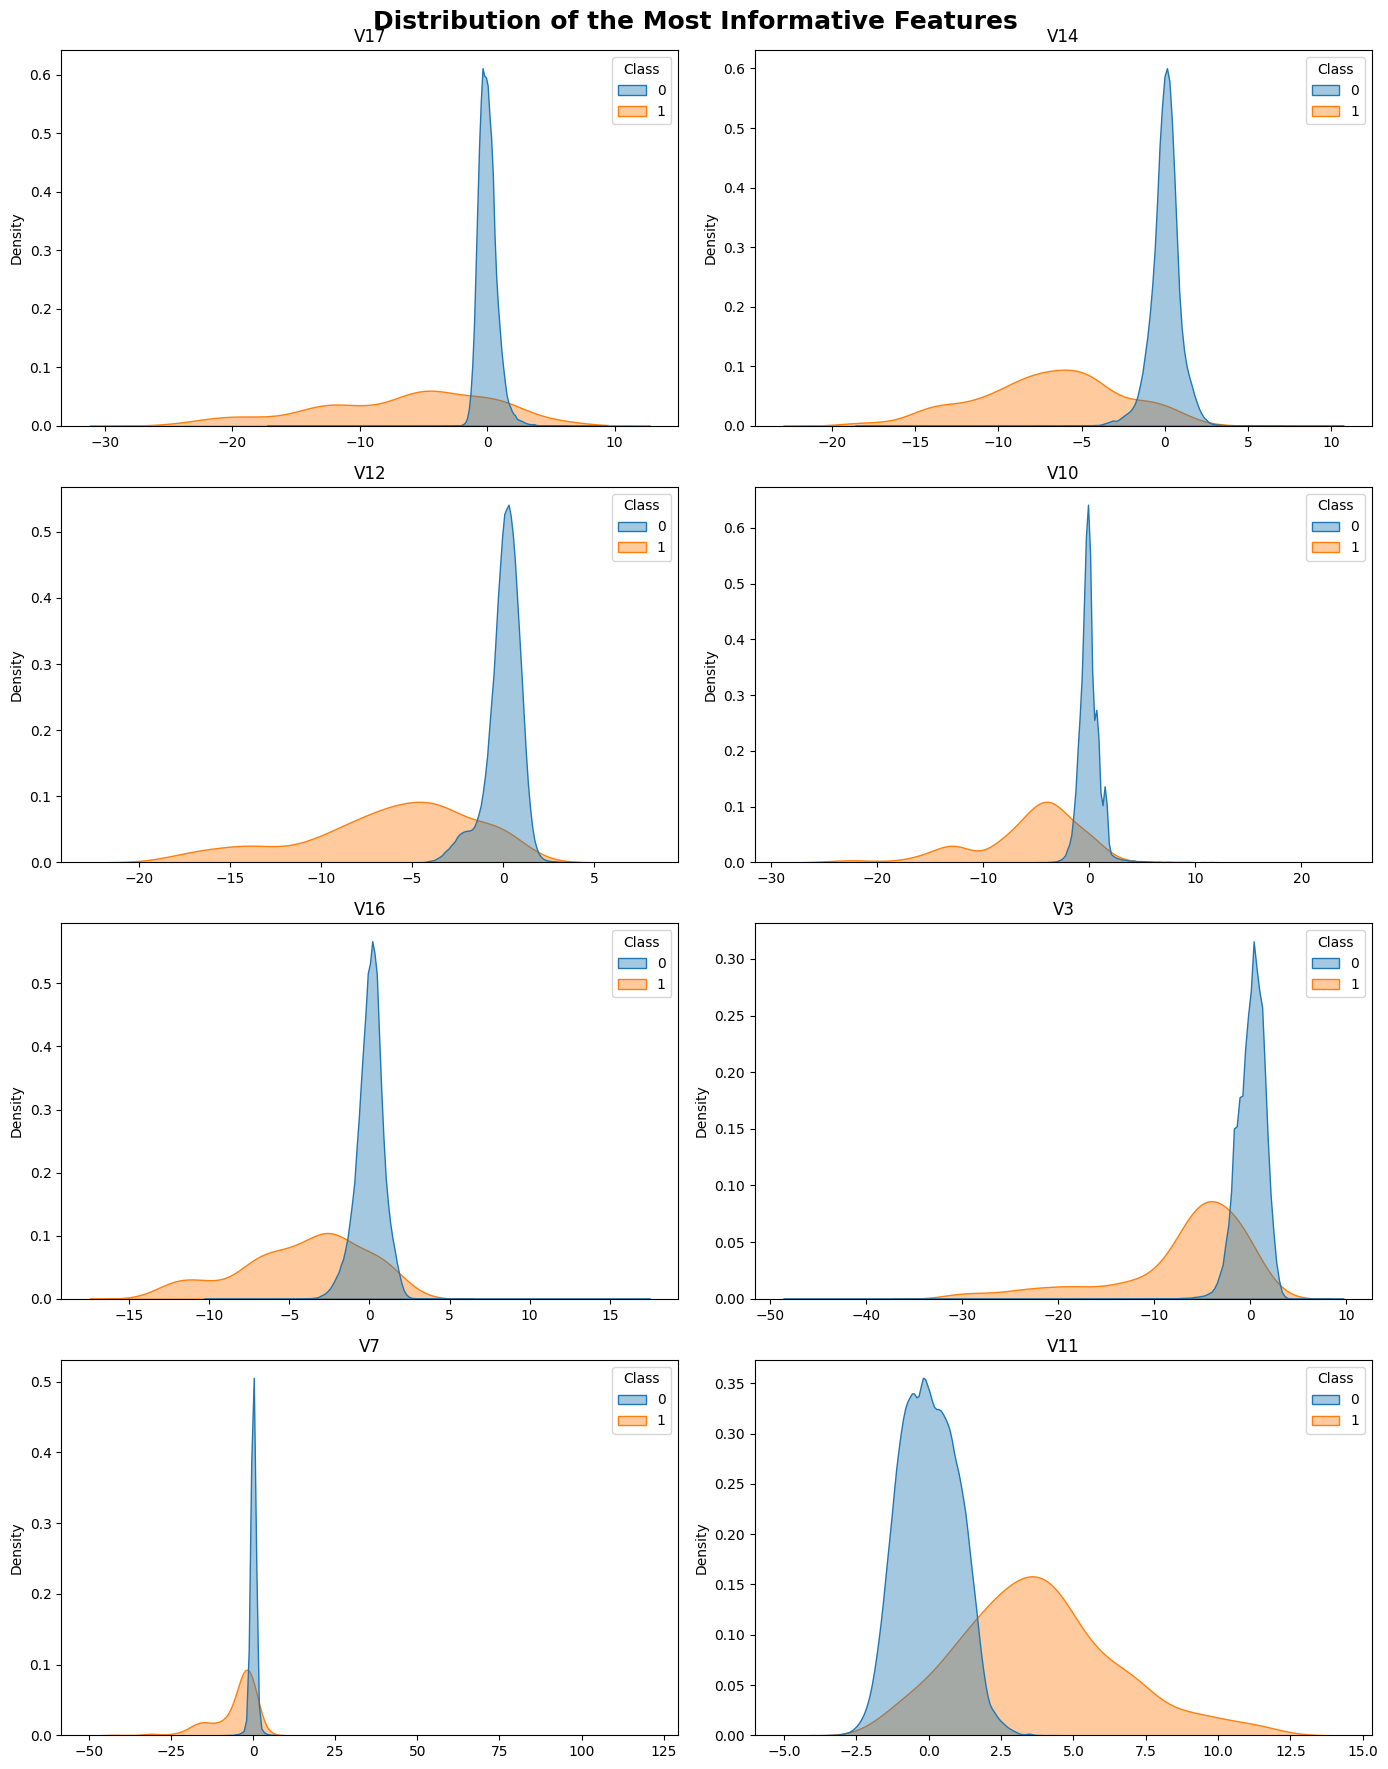

In [24]:
# Distribution of the Most Informative Features
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

axes = axes.flatten()

for ax, feature in zip(axes, top_features):

    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

# Hide any unused axes
for ax in axes[len(top_features):]:
    ax.set_visible(False)

plt.suptitle(
    "Distribution of the Most Informative Features",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

### **Observation**
The selected features exhibit noticeable differences between legitimate and fraudulent transactions.

For several variables, the density curves of the two classes are clearly separated, indicating that these features contain useful discriminatory information. In contrast, other features display greater overlap, suggesting that they are less informative when considered individually.

These observations support the results of the correlation analysis and demonstrate that the selected PCA components capture meaningful patterns related to fraudulent activity.

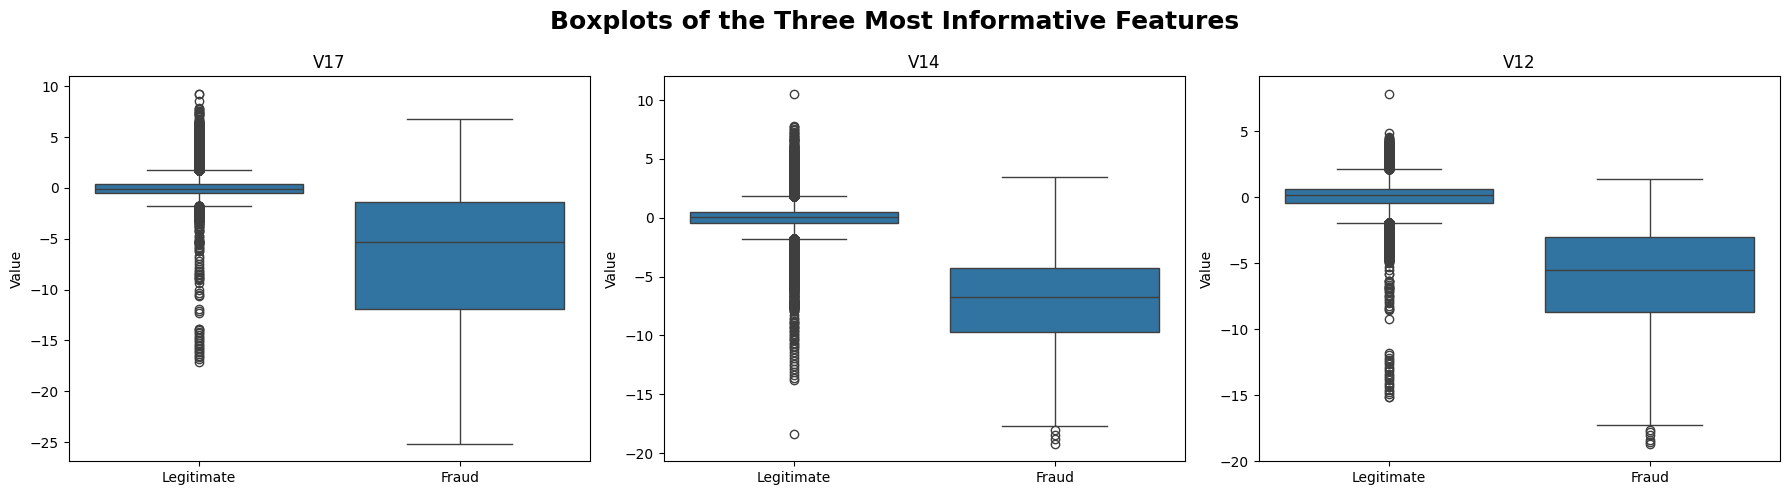

In [25]:
# Boxplots of the Top Three Features
top3_features = top_features[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top3_features):

    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )

    ax.set_xticklabels(["Legitimate", "Fraud"])
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Value")

plt.suptitle(
    "Boxplots of the Three Most Informative Features",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

### **Observation**
The boxplots reveal noticeable differences between legitimate and fraudulent transactions across the most informative features.

For each selected feature, the median values and interquartile ranges differ substantially between the two classes. Although some overlap remains, the distributions are clearly shifted, indicating that these variables capture meaningful patterns associated with fraudulent activity.

The presence of overlapping values also suggests that no single feature can perfectly separate the classes. Therefore, combining multiple variables within machine learning models is expected to provide substantially better predictive performance than relying on any individual feature.

# **DATA PREPROCESSING**
Data preprocessing transforms the raw dataset into a format suitable for machine learning and deep learning algorithms.

The preprocessing pipeline is designed based on the findings obtained during the exploratory data analysis and aims to ensure reliable model training while preventing data leakage.

The following preprocessing steps will be performed:

* handling duplicate records;
* feature scaling;
* train-test split;
* handling class imbalance.

## <u>Handling Duplicate Records</u>
Duplicate records may arise from repeated transactions, data collection artifacts, or legitimate identical operations.

In financial transaction datasets, duplicate observations do not necessarily indicate data quality issues. Therefore, duplicate records should not be removed automatically without careful consideration.

This section evaluates the extent of duplicate records before deciding whether any action is required.

In [26]:
# Duplicate Records
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate records : {duplicate_count:,}")
print(f"Percentage        : {duplicate_percentage:.3f}%")

Duplicate records : 1,081
Percentage        : 0.380%


In [27]:
# 4.2.2 Duplicate Records by Class
duplicates = df[df.duplicated(keep=False)]

duplicate_summary = (
    duplicates["Class"]
    .value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame(name="Duplicate Records")
)

display(duplicate_summary)

,Duplicate Records
Class,
Legitimate,1822
Fraud,32


### **Observation**

The dataset contains **1,081 duplicate records**, representing approximately **0.38%** of all observations.

The duplicate records are predominantly associated with legitimate transactions, while only a small proportion corresponds to fraudulent transactions. This suggests that duplicate observations are not concentrated within the minority class and are unlikely to introduce systematic bias toward fraud detection.

Although the proportion of duplicate records is relatively small (0.38%), duplicate observations may arise from either repeated legitimate transactions or duplicated data entries.

To avoid introducing unnecessary bias and to preserve potentially valid financial transactions, duplicate records will be retained throughout this project.

This decision ensures that the models are trained on the complete dataset while maintaining the original data distribution.

## <u>Train-Test Split</u>
Before applying any preprocessing techniques that learn from the data, the dataset must be divided into independent training and testing subsets.

Performing the train-test split at this stage prevents information leakage, ensuring that the test data remain completely unseen during model development.

A stratified split is used to preserve the original class distribution in both subsets, which is particularly important for highly imbalanced classification problems such as fraud detection.

In [28]:
# Define Features and Target
X = df.drop(columns="Class")
y = df["Class"]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (284807, 30)
Target shape:   (284807,)


### **Observation**
The predictor matrix `(X)` contains all explanatory variables, while the target vector `(y)` contains the class labels indicating whether a transaction is legitimate or fraudulent.

Separating predictors from the target variable is the first step before splitting the data into training and testing sets.

In [29]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Split 1: train_full (80%) / test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Split 2: train (80% of train_full) / validation (20% of train_full)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE
)

print("=" * 50)
print("Train-Test Split Completed")
print("=" * 50)

print(f"\nTrain set:      {X_train.shape[0]} rows ({y_train.mean()*100:.4f}% fraud)")
print(f"Validation set: {X_val.shape[0]} rows ({y_val.mean()*100:.4f}% fraud)")
print(f"Test set:       {X_test.shape[0]} rows ({y_test.mean()*100:.4f}% fraud)")

Train-Test Split Completed

Train set:      182276 rows (0.1728% fraud)
Validation set: 45569 rows (0.1734% fraud)
Test set:       56962 rows (0.1720% fraud)


In [30]:
# Class Distribution After Split
train_distribution = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .rename("Training Set (%)")
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .mul(100)
    .rename("Testing Set (%)")
)

val_distribution = (
    y_val.value_counts(normalize=True)
    .mul(100)
    .rename("Validation Set (%)")
)

distribution = pd.concat(
    [train_distribution, test_distribution, val_distribution],
    axis=1
)

display(distribution.round(3))

,Training Set (%),Testing Set (%),Validation Set (%)
Class,,,
0,99.827,99.828,99.827
1,0.173,0.172,0.173


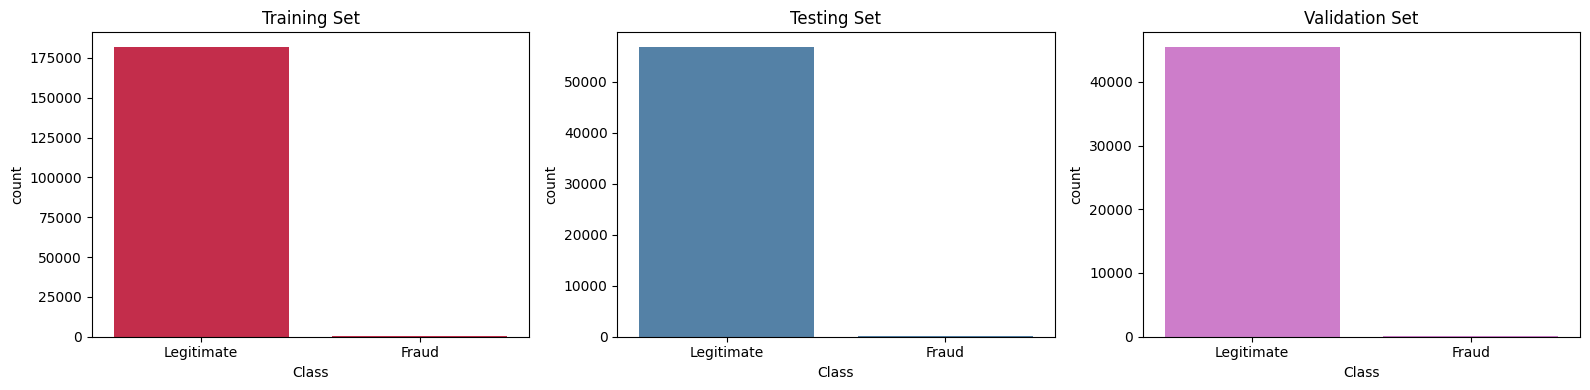

In [31]:
# Class Distribution After Split
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x=y_train, ax=axes[0], color="crimson")

axes[0].set_title("Training Set")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

sns.countplot(x=y_test, ax=axes[1], color="steelblue")

axes[1].set_title("Testing Set")
axes[1].set_xticklabels(["Legitimate", "Fraud"])

sns.countplot(x=y_val, ax=axes[2], color="orchid")

axes[2].set_title("Validation Set")
axes[2].set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()

plt.show()

### **Observation**
The class distributions in the training and testing sets remain nearly identical to the original dataset.

This confirms that stratified sampling successfully preserved the severe class imbalance, ensuring that both subsets accurately represent the underlying data distribution.

## <u>Feature Scaling</u>
Many machine learning and deep learning algorithms are sensitive to differences in feature scales.

The exploratory analysis showed that the Time and Amount variables have substantially different numerical ranges from the remaining features. In contrast, the anonymized PCA components `(V1–V28)` are already standardized as part of the original data preparation process.

Therefore, feature scaling will be applied **only** to the Time and Amount variables. To prevent data leakage, the scaler will be fitted exclusively on the training set and then applied to both the training and testing sets.

In [32]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit StandardScaler
scaler.fit(X_train[["Time", "Amount"]])

StandardScaler()

In [33]:
# Scale Time and Amount
# Create copies to preserve the original datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_val_scaled = X_val.copy()

# Scale only the original numerical features
X_train_scaled[["Time", "Amount"]] = scaler.transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

X_val_scaled[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

In [34]:
# Verify Scaling
display(
    X_train_scaled[["Time", "Amount"]].describe().round(2)
)

,Time,Amount
count,182276.00,182276.00
mean,0.00,-0.00
std,1.00,1.00
min,-2.00,-0.36
25%,-0.86,-0.34
50%,-0.21,-0.27
75%,0.94,-0.04
max,1.64,79.68


### **Observation**
The scaled features have approximately zero mean and unit variance, confirming that the transformation was successfully applied.

Only the Time and Amount variables were standardized, while the PCA components remained unchanged because they were already normalized during the original data preparation process.

## <u>Handling Class Imbalance</u>
The exploratory data analysis revealed that the dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of all observations.

Training machine learning models directly on such data may result in a strong bias toward the majority class, causing the models to achieve high accuracy while failing to detect fraudulent transactions.

Several techniques can be used to address class imbalance, including undersampling, oversampling, class weighting, and synthetic sample generation.

For this project, the Synthetic Minority Over-sampling Technique (SMOTE) is selected because it generates new synthetic minority class examples instead of simply duplicating existing observations. This approach generally improves the model's ability to learn fraud-related patterns while preserving information from the majority class.

To prevent information leakage, SMOTE will be applied **only to the training set** after the train-test split.

In [35]:
# Class Distribution Before SMOTE
class_distribution_before = (
    y_train.value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame(name="Count")
)

display(class_distribution_before)

,Count
Class,
Legitimate,181961
Fraud,315


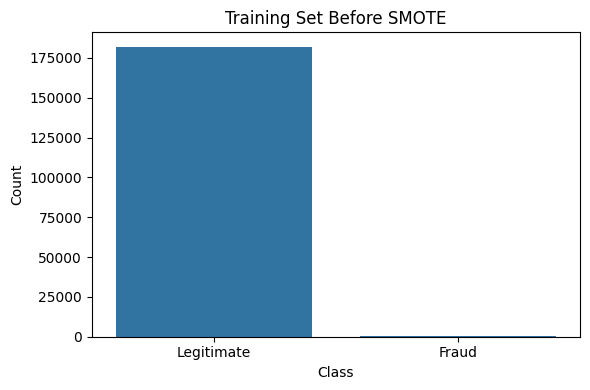

In [36]:
# Training Set Before SMOTE
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title("Training Set Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

### **Observation**
The training data exhibit a severe class imbalance, with legitimate transactions vastly outnumbering fraudulent ones.

Without appropriate balancing techniques, machine learning algorithms may become biased toward the majority class, leading to poor fraud detection despite achieving high overall accuracy.

In [37]:
# Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [38]:
# Verify SMOTE
class_distribution_after = (
    y_train_balanced.value_counts()
    .rename(index={0:"Legitimate",1:"Fraud"})
    .to_frame(name="Count")
)

display(class_distribution_after)

,Count
Class,
Legitimate,181961
Fraud,181961


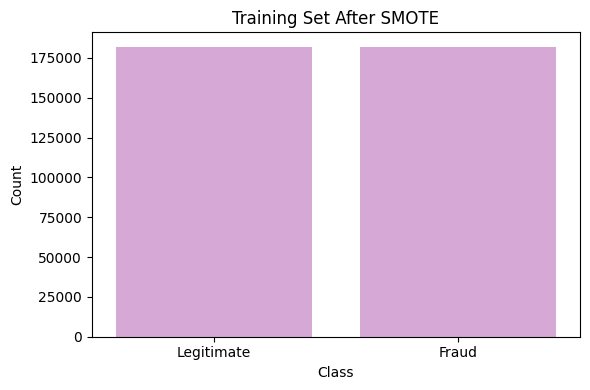

In [39]:
# Training Set After SMOTE
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_balanced, color="plum")

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title("Training Set After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [40]:
# Comparison of Class Distribution
comparison = pd.DataFrame({
    "Before SMOTE": y_train.value_counts().sort_index(),
    "After SMOTE": y_train_balanced.value_counts().sort_index()
})

comparison.index = ["Legitimate", "Fraud"]

display(comparison)

,Before SMOTE,After SMOTE
Legitimate,181961,181961
Fraud,315,181961


### **Observation**
After applying SMOTE, the minority class has been synthetically expanded to match the number of legitimate transactions.

Unlike simple oversampling, SMOTE generates new synthetic observations based on the nearest minority-class neighbors rather than duplicating existing fraud cases. This reduces the risk of overfitting while providing the model with a more balanced training dataset.

Importantly, the test set remains completely unchanged, ensuring an unbiased evaluation of model performance.

In [41]:
print(X_train_balanced.shape)
print(y_train_balanced.shape)

print(X_test_scaled.shape)
print(y_test.shape)

print(X_val_scaled.shape)
print(y_val.shape)

(363922, 30)
(363922,)
(56962, 30)
(56962,)
(45569, 30)
(45569,)


# **Baseline Model: Logistic Regression**

A class-balanced Logistic Regression provides a simple supervised baseline against
which the anomaly-detection and hybrid approaches are compared. Because the dataset
is highly imbalanced, evaluation focuses on precision, recall, F1, ROC-AUC, and
PR-AUC rather than accuracy.

## <u>Modeling Strategy</u>
Several classification algorithms with different underlying learning principles are evaluated in this project.

The objective is to compare simple linear models, tree-based algorithms, ensemble methods, and gradient boosting techniques in order to identify the most effective approach for fraud detection.

Each model will be trained using the balanced training dataset produced by SMOTE and evaluated on the untouched testing dataset to ensure an unbiased assessment of generalization performance.

In [42]:
# Universal Model Evaluation Function

def evaluate_model(
    model_name,
    y_test,
    y_pred,
    y_score
):
    """
    Evaluate a binary fraud detection model.

    Parameters
    ----------
    model_name : str
        Name of the model.

    y_test : pandas.Series or numpy.ndarray
        True target labels.

    y_pred : pandas.Series or numpy.ndarray
        Predicted class labels.

    y_score : pandas.Series or numpy.ndarray
        Fraud/anomaly score. Higher value should indicate
        higher probability/risk of fraud.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    # ------------------------------------------------------
    # Evaluation Metrics
    # ------------------------------------------------------

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_score
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_score
        ),
    }

    # ------------------------------------------------------
    # Print Metrics
    # ------------------------------------------------------

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    for metric, value in metrics.items():

        if metric != "Model":
            print(f"{metric:<10}: {value:.4f}")

    # ------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

    # ------------------------------------------------------
    # ROC Curve
    # ------------------------------------------------------

    RocCurveDisplay.from_predictions(
        y_test,
        y_score
    )

    plt.title(
        f"{model_name} - ROC Curve"
    )

    plt.show()

    # ------------------------------------------------------
    # Precision-Recall Curve
    # ------------------------------------------------------

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score
    )

    plt.title(
        f"{model_name} - Precision-Recall Curve"
    )

    plt.show()

    return metrics

## <u>Universal Model Evaluation Function</u>
To ensure a fair and consistent comparison across all machine learning models, a reusable evaluation function is implemented.

The function automatically generates class predictions, computes the predicted scores required for probability-based evaluation metrics, and calculates the key performance measures used throughout this project:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* PR-AUC

In addition, the function visualizes the model performance using a confusion matrix, ROC curve, and Precision–Recall curve.

The evaluation results are returned as a dictionary, enabling straightforward comparison of multiple models in the final performance summary.

## <u>Logistic Regression</u>
Logistic Regression is selected as the baseline model because of its simplicity, interpretability, and widespread use in binary classification tasks.

Although fraud detection is a complex problem, Logistic Regression provides an important reference point for evaluating the performance improvements achieved by more sophisticated machine learning algorithms.

The model is trained using the balanced training dataset produced by SMOTE and evaluated on the original testing dataset.

In [43]:
# Create Logistic Regression Model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver="lbfgs"
)

In [44]:
# Train Logistic Regression
lr_model.fit(
    X_train_balanced,
    y_train_balanced
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [45]:
# For Validation
lr_val_prob = lr_model.predict_proba(
    X_val_scaled
)[:, 1]

lr_val_pred = (
    lr_val_prob >= 0.5
).astype(int)

In [46]:
# Use the test data
lr_test_prob = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

lr_test_pred = (
    lr_test_prob >= 0.5
).astype(int)

Logistic Regression
Accuracy  : 0.9743
Precision : 0.0576
Recall    : 0.9082
F1-score  : 0.1083
ROC-AUC   : 0.9736
PR-AUC    : 0.7177


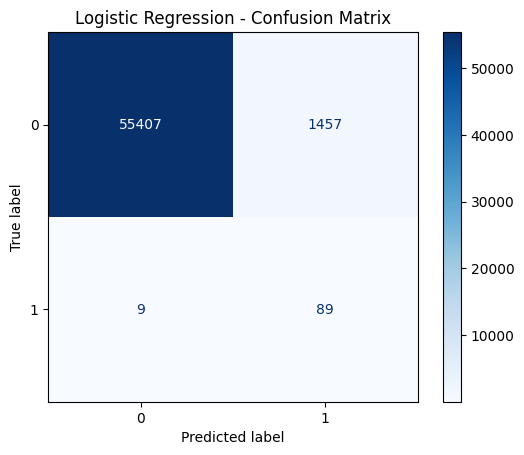

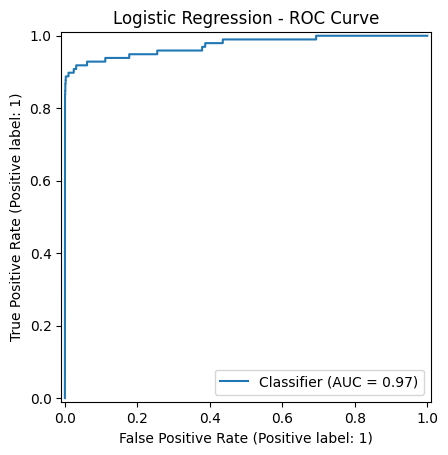

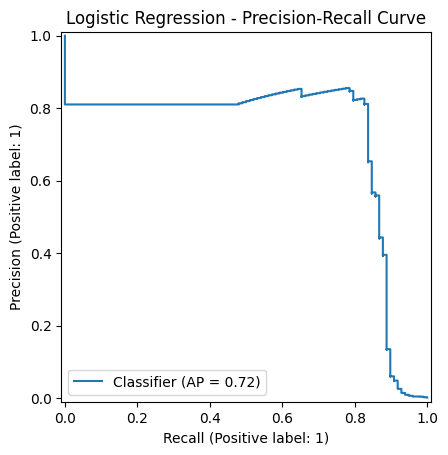

In [47]:
results_lr = evaluate_model(
    model_name="Logistic Regression",
    y_test=y_test,
    y_pred=lr_test_pred,
    y_score=lr_test_prob
)

### **Observation**

Logistic Regression serves as the baseline model for this project.

Despite its simplicity, the model establishes a reference level of performance against which more advanced machine learning algorithms can be compared.

The evaluation metrics obtained in this section will be used later to assess whether tree-based ensemble methods and gradient boosting techniques provide meaningful improvements in fraud detection performance.

## <u>Isolation Forest</u>

Isolation Forest detects anomalies by randomly partitioning the feature space.
Anomalous points tend to be isolated in fewer random splits than normal points, so
they receive a shorter average path length across the ensemble of trees — this path
length is converted into an anomaly score. `contamination="auto"` is used rather
than hard-coding the true fraud rate, since in a real deployment the true rate is not
known in advance.

In [48]:
# Select Normal Transactions
X_train_normal = X_train_scaled[
    y_train.values == 0
]

print("Normal training transactions:",
      X_train_normal.shape)

Normal training transactions: (181961, 30)


In [49]:
# Create Isolation Forest Model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

In [50]:
# Train Isolation Forest
iso_forest.fit(X_train_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [51]:
# Validation Anomaly Score
iso_val_score = -iso_forest.decision_function(
    X_val_scaled
)

In [52]:
# Validation Anomaly Score
iso_val_score = -iso_forest.decision_function(
    X_val_scaled
)

# Higher score = more anomalous

In [53]:
iso_threshold = np.percentile(
    iso_val_score,
    95
)

iso_val_pred = (
    iso_val_score >= iso_threshold
).astype(int)

Isolation Forest
Accuracy  : 0.9510
Precision : 0.0276
Recall    : 0.7975
F1-score  : 0.0534
ROC-AUC   : 0.9302
PR-AUC    : 0.0760


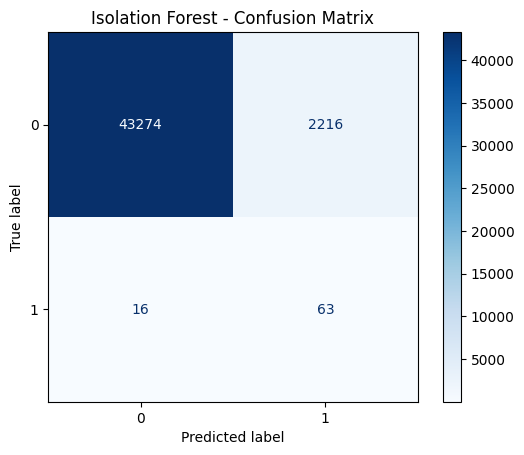

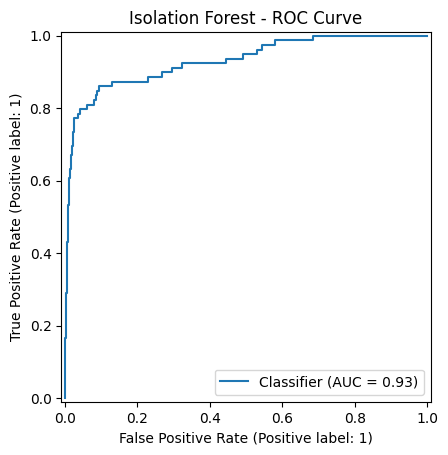

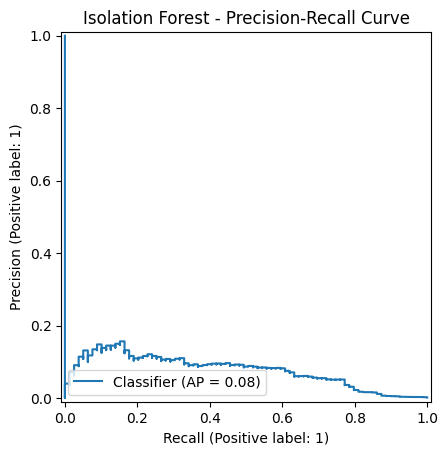

In [54]:
results_val_iso = evaluate_model(
    model_name="Isolation Forest",
    y_test=y_val,
    y_pred=iso_val_pred,
    y_score=iso_val_score
)

In [55]:
# Test Anomaly Score
iso_test_score = -iso_forest.decision_function(
    X_test_scaled
)

In [56]:
# Use Validation Threshold
iso_test_pred = (
    iso_test_score >= iso_threshold
).astype(int)

Isolation Forest
Accuracy  : 0.9495
Precision : 0.0285
Recall    : 0.8571
F1-score  : 0.0552
ROC-AUC   : 0.9540
PR-AUC    : 0.1254


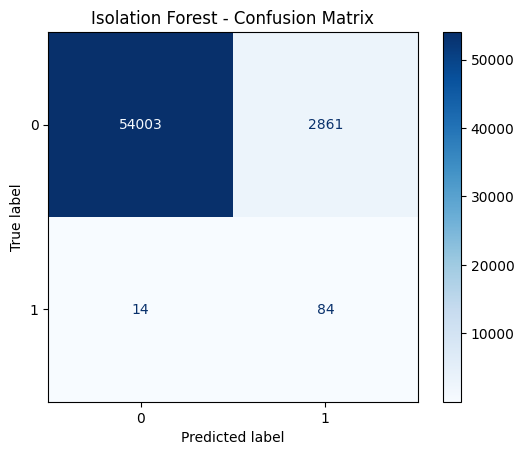

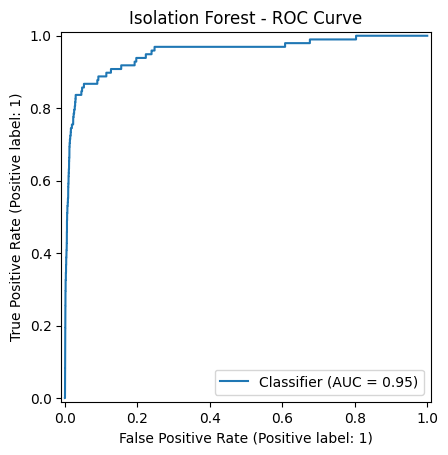

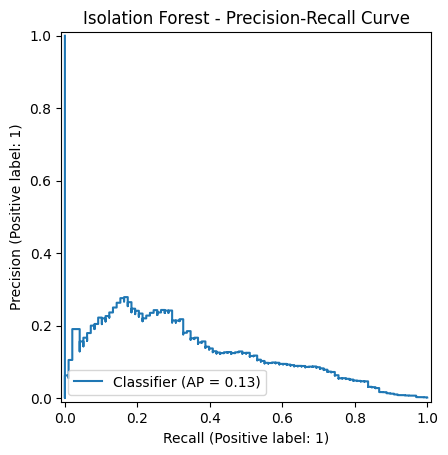

In [57]:
results_iso = evaluate_model(
    model_name="Isolation Forest",
    y_test=y_test,
    y_pred=iso_test_pred,
    y_score=iso_test_score
)

## <u>Autoencoder</u>

A neural-network Autoencoder is trained **only on legitimate transactions** from the
training set so it learns to reconstruct normal transaction behavior well. Fraudulent
(and other anomalous) transactions are expected to have a higher reconstruction error
because the network was never trained to reconstruct them. The reconstruction-error
threshold is derived from the distribution of errors on **legitimate validation
transactions** (95th percentile), not an arbitrary invented cutoff.

In [58]:
# Normal Training Data
X_train_normal_ae = X_train_scaled[
    y_train.values == 0
]

print(
    "Normal training data:",
    X_train_normal_ae.shape
)

Normal training data: (181961, 30)


In [59]:
input_dim = X_train_normal_ae.shape[1]

# ------------------------------------------------------
# Input
# ------------------------------------------------------

input_layer = Input(
    shape=(input_dim,)
)

In [60]:
autoencoder = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(input_dim, activation="linear"),
])

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ])
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Early Stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train autoencoder
history = autoencoder.fit(
    X_train_normal_ae,
    X_train_normal_ae,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4625 - loss: 0.5918 - precision: 1.0000 - recall: 0.0927 - val_accuracy: 0.5698 - val_loss: 0.4043 - val_precision: 1.0000 - val_recall: 0.1298
Epoch 2/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step - accuracy: 0.5934 - loss: 0.3563 - precision: 1.0000 - recall: 0.1409 - val_accuracy: 0.6136 - val_loss: 0.3222 - val_precision: 1.0000 - val_recall: 0.1490
Epoch 3/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 839us/step - accuracy: 0.6347 - loss: 0.2982 - precision: 1.0000 - recall: 0.1580 - val_accuracy: 0.6468 - val_loss: 0.2816 - val_precision: 1.0000 - val_recall: 0.1588
Epoch 4/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step - accuracy: 0.6535 - loss: 0.2710 - precision: 1.0000 - recall: 0.1638 - val_accuracy: 0.6599 - val_loss: 0.2630 - val_precision: 1.0000 - val_recall: 0.1616
Epoch 5/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step - accuracy: 0.6636 - loss: 0.2570 - precision: 1.0000 - recall: 0.1667 - val_accuracy: 0.6672 - val_

In [62]:
# Autoencoder - Validation
X_val_reconstructed = autoencoder.predict(
    X_val_scaled,
    verbose=0
)

# Reconstruction Error
ae_val_error = np.mean(
    np.square(
        X_val_scaled -
        X_val_reconstructed
    ),
    axis=1
)

# Higher reconstruction error means the transaction looks less like the normal transactions the Autoencoder learned.

In [93]:
# Adaptive Risk Threshold
# ----------------------------------------------------------
legitimate_val_mask = (
    y_val.to_numpy() == 0
)

# Legitimate Validation Hybrid Scores

legitimate_hybrid_scores = (
    hybrid_val_score[
        legitimate_val_mask
    ]
)

# ----------------------------------------------------------
# 95th Percentile Threshold

adaptive_threshold = np.percentile(
    legitimate_hybrid_scores,
    95
)

print(
    "Adaptive Risk Threshold:",
    adaptive_threshold
)

Adaptive Risk Threshold: 0.33500671916714936


In [94]:
# Adaptive Autoencoder Threshold
legitimate_ae_val_errors = (
    ae_val_error[
        legitimate_val_mask
    ]
)

ae_threshold = np.percentile(
    legitimate_ae_val_errors,
    95
)

print(
    "Autoencoder Threshold:",
    ae_threshold
)

Autoencoder Threshold: 0.47954179410935255


In [95]:
ae_val_pred = (
    ae_val_error >= ae_threshold
).astype(int)

Autoencoder
Accuracy  : 0.9498
Precision : 0.0282
Recall    : 0.8354
F1-score  : 0.0545
ROC-AUC   : 0.9373
PR-AUC    : 0.3900


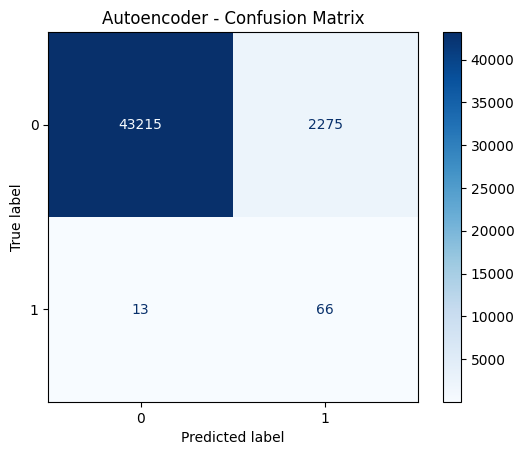

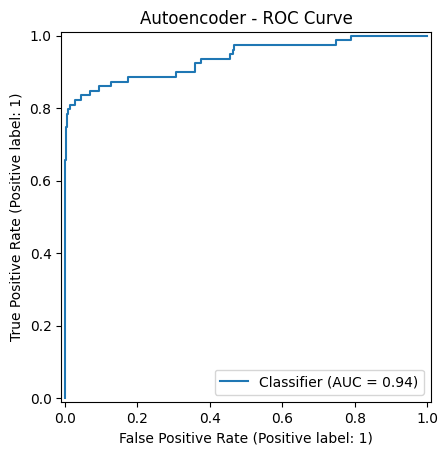

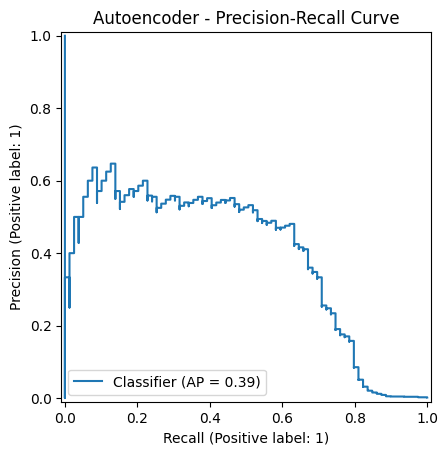

In [96]:
results_val_ae = evaluate_model(
    model_name="Autoencoder",
    y_test=y_val,
    y_pred=ae_val_pred,
    y_score=ae_val_error
)

In [97]:
# Autoencoder - Test
X_test_reconstructed = autoencoder.predict(
    X_test_scaled,
    verbose=0
)

ae_test_error = np.mean(
    np.square(
        X_test_scaled -
        X_test_reconstructed
    ),
    axis=1
)

ae_test_pred = (
    ae_test_error >= ae_threshold
).astype(int)

Autoencoder
Accuracy  : 0.9495
Precision : 0.0289
Recall    : 0.8673
F1-score  : 0.0558
ROC-AUC   : 0.9511
PR-AUC    : 0.5933


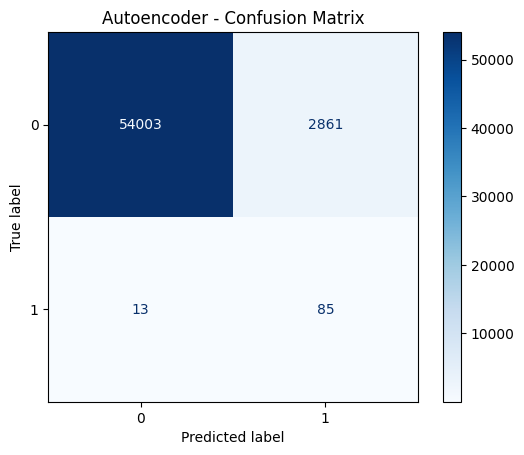

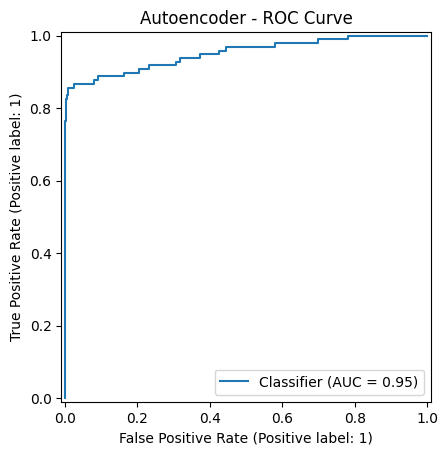

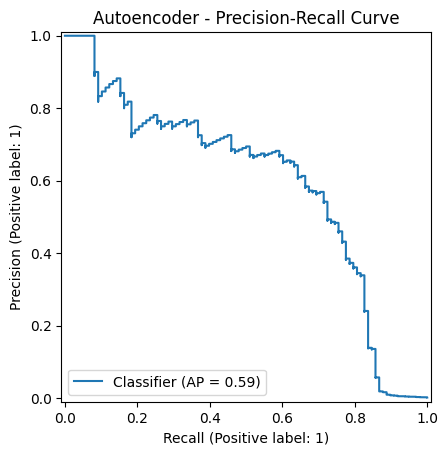

In [98]:
# Evaluate
results_ae = evaluate_model(
    model_name="Autoencoder",
    y_test=y_test,
    y_pred=ae_test_pred,
    y_score=ae_test_error
)

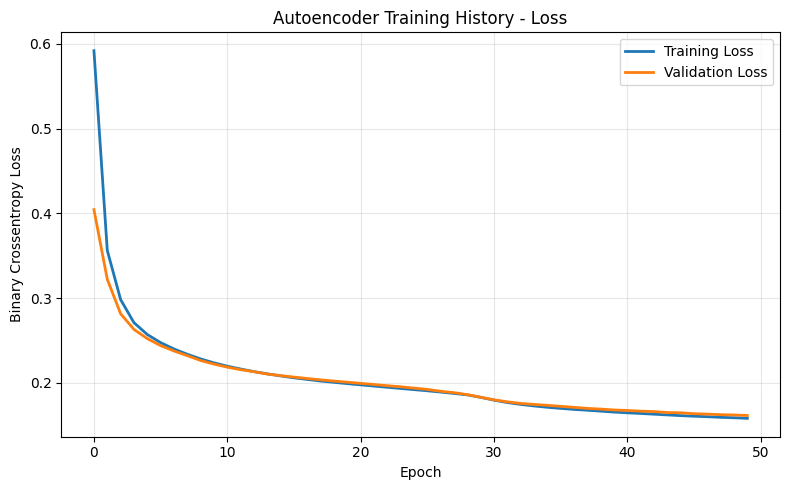

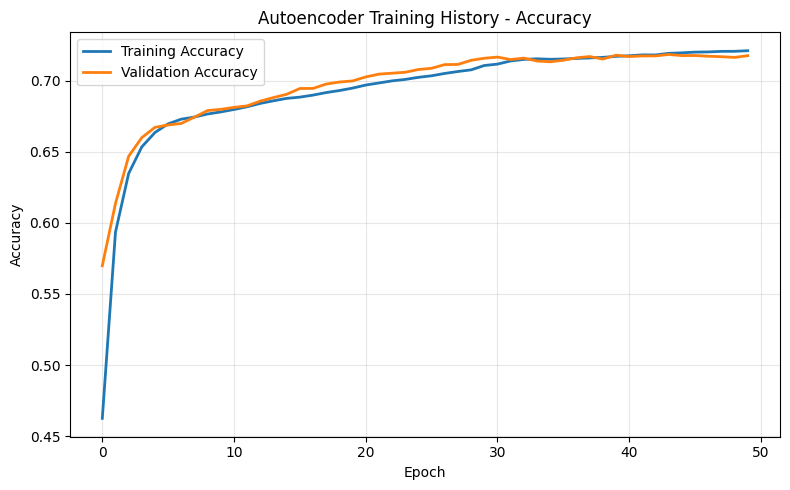

In [99]:
# Autoencoder Learning Curves

# Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Autoencoder Training History - Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Autoencoder Training History - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Hybrid Fraud Risk Score (Main Contribution)**

The core contribution of this project is a **Hybrid Fraud Risk Scoring Framework**
that combines the normalized Isolation Forest anomaly score and the normalized
Autoencoder reconstruction error into a single, unified **Fraud Risk Score (0-100)**:

`Fraud Risk Score = 100 x (0.50 x Isolation Forest Score + 0.50 x Autoencoder Score)`

This is presented as a project-level engineering framework, not a novel research
algorithm — both Isolation Forest and Autoencoders are well-established techniques.
The score is a **weighted heuristic**, not a statistically calibrated probability of
fraud, since no probability calibration step (e.g. Platt scaling or isotonic
regression against ground truth) has been applied.

In [100]:
# Now combine the two anomaly scores.
# The scores have different ranges, so normalize them first.

# ==========================================================
# Hybrid Model
# ==========================================================

iso_score_scaler = MinMaxScaler()
ae_score_scaler = MinMaxScaler()

# ----------------------------------------------------------
# Normalize Validation Scores
# ----------------------------------------------------------

iso_val_norm = iso_score_scaler.fit_transform(
    np.asarray(iso_val_score).reshape(-1, 1)
).ravel()

ae_val_norm = ae_score_scaler.fit_transform(
    np.asarray(ae_val_error).reshape(-1, 1)
).ravel()

In [101]:
# Find Best Hybrid Weight and Threshold

best_f1 = -1

best_iso_weight = None

best_threshold = None

for iso_weight in np.arange(
    0.0,
    1.1,
    0.1
):

    ae_weight = 1 - iso_weight

    # ------------------------------------------------------
    # Hybrid Validation Score
    # ------------------------------------------------------

    hybrid_val_score = (
        iso_weight * iso_val_norm
        +
        ae_weight * ae_val_norm
    )

    # ------------------------------------------------------
    # Try Different Thresholds
    # ------------------------------------------------------

    for percentile in np.arange(
        90,
        100,
        1
    ):

        threshold = np.percentile(
            hybrid_val_score,
            percentile
        )

        hybrid_val_pred = (
            hybrid_val_score >= threshold
        ).astype(int)

        current_f1 = f1_score(
            y_val,
            hybrid_val_pred,
            zero_division=0
        )

        if current_f1 > best_f1:

            best_f1 = current_f1

            best_iso_weight = iso_weight

            best_threshold = threshold

In [102]:
# Best Hybrid Configuration
best_ae_weight = 1 - best_iso_weight

print(
    "Best Isolation Forest Weight:",
    best_iso_weight
)

print(
    "Best Autoencoder Weight:",
    best_ae_weight
)

print(
    "Best Validation Threshold:",
    best_threshold
)

print(
    "Best Validation F1:",
    best_f1
)

Best Isolation Forest Weight: 0.0
Best Autoencoder Weight: 1.0
Best Validation Threshold: 0.015042213858661979
Best Validation F1: 0.23551401869158878


In [105]:
# Hybrid - Test

iso_test_norm = iso_score_scaler.transform(
    iso_test_score.reshape(-1, 1)
).ravel()

ae_test_norm = ae_score_scaler.transform(
    ae_test_error.to_numpy().reshape(-1, 1)
).ravel()

In [106]:
# Hybrid Test Score

hybrid_test_score = (
    best_iso_weight * iso_test_norm
    +
    best_ae_weight * ae_test_norm
)

In [107]:
# Apply the validation threshold

# Hybrid Prediction
hybrid_test_pred = (
    hybrid_test_score >= best_threshold
).astype(int)

Hybrid Isolation Forest + Autoencoder
Accuracy  : 0.9913
Precision : 0.1464
Recall    : 0.8367
F1-score  : 0.2492
ROC-AUC   : 0.9511
PR-AUC    : 0.5933


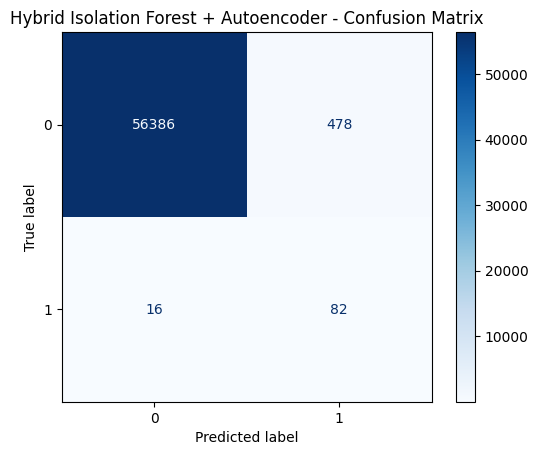

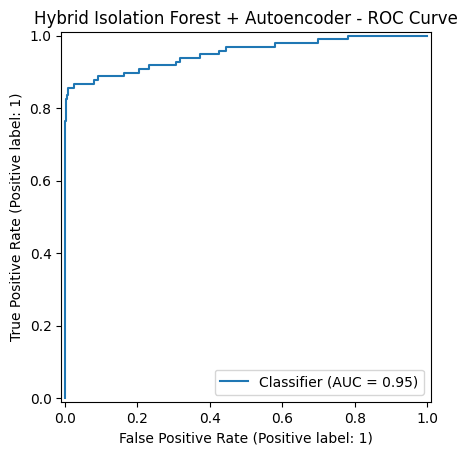

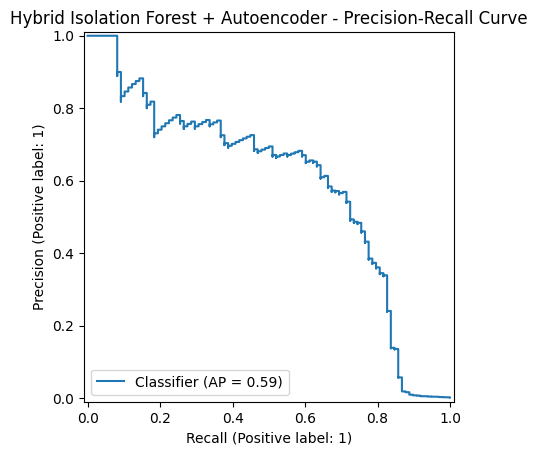

In [108]:
# Evaluate
results_hybrid = evaluate_model(
    model_name="Hybrid Isolation Forest + Autoencoder",
    y_test=y_test,
    y_pred=hybrid_test_pred,
    y_score=hybrid_test_score
)

## <u>Convert Hybrid Score to 0-100 Risk Score</u>

In [109]:
# Risk Score: 0-100
risk_score = (
    hybrid_test_score /
    hybrid_test_score.max()
) * 100

risk_score = np.clip(
    risk_score,
    0,
    100
)

## <u>Risk Categories</u>

In [110]:
def risk_category(score):

    if score <= 30:
        return "Low Risk"

    elif score <= 70:
        return "Medium Risk"

    else:
        return "High Risk"

In [111]:
risk_categories = [
    risk_category(score)
    for score in risk_score
]

## <u>Final Fraud Detection Output</u>

In [118]:
# Final Fraud Detection Results

risk_results = pd.DataFrame({

    "Actual Class":
        y_test.to_numpy(),

    "Hybrid Risk Score":
        hybrid_test_score,

    "Risk Score (0-100)":
        risk_score,

    "Risk Category":
        risk_categories,

    "Fraud Prediction":
        hybrid_test_pred
})

random_samples = risk_results.sample(n=10)

display(random_samples)

,Actual Class,Hybrid Risk Score,Risk Score (0-100),Risk Category,Fraud Prediction
56735,0,0.000882,0.091070,Low Risk,0
31798,0,0.006407,0.661398,Low Risk,0
8418,0,0.000732,0.075576,Low Risk,0
31486,0,0.002646,0.273146,Low Risk,0
56647,0,0.001855,0.191448,Low Risk,0
37581,0,0.006089,0.628533,Low Risk,0
35669,0,0.001158,0.119498,Low Risk,0
51752,0,0.015897,1.640924,Low Risk,1
2088,0,0.004212,0.434808,Low Risk,0
22750,0,0.000327,0.033806,Low Risk,0


# **Explainable Fraud Detection**

For any transaction, `explain_transaction(transaction_index)` returns a human-readable
breakdown of its risk score, risk level, component scores, the detected anomaly
signals, and the final decision. Explanations are limited strictly to signals that
can be derived from the fields actually present in this dataset (anomaly scores and
transaction amount) — location, merchant, customer, and device signals are **not**
fabricated, since those fields do not exist in this dataset.

In [119]:
# Explainable Fraud Detection

# ----------------------------------------------------------
# Amount Threshold
# ----------------------------------------------------------
# Used only as an explanatory signal.
# The 95th percentile is calculated from training data,
# so the test data is not used to create this threshold.

amount_threshold = X_train["Amount"].quantile(0.95)


# ----------------------------------------------------------
# Transaction Explanation Function
# ----------------------------------------------------------

def explain_transaction(transaction_index):
    """
    Provide a human-readable explanation for a transaction.

    Explanation is based only on signals available in this
    dataset:

        1. Transaction Amount
        2. Isolation Forest anomaly score
        3. Autoencoder reconstruction error
        4. Hybrid risk score
        5. Adaptive risk threshold
        6. Final risk score
        7. Risk category
        8. Final fraud decision

    Location, merchant, customer, and device information
    are not used because these fields are not present
    in the dataset.
    """

    # ------------------------------------------------------
    # Validate Transaction Index
    # ------------------------------------------------------

    if not isinstance(transaction_index, (int, np.integer)):
        raise TypeError(
            "transaction_index must be an integer."
        )

    if (
        transaction_index < 0
        or transaction_index >= len(X_test)
    ):
        raise IndexError(
            f"Transaction index must be between "
            f"0 and {len(X_test) - 1}."
        )

    # ------------------------------------------------------
    # Get Original Transaction
    # ------------------------------------------------------

    transaction = X_test.iloc[transaction_index]

    # ------------------------------------------------------
    # Transaction Amount
    # ------------------------------------------------------

    transaction_amount = transaction["Amount"]

    # ------------------------------------------------------
    # Model Scores
    # ------------------------------------------------------

    iso_score = iso_test_score[
        transaction_index
    ]

    ae_error = ae_test_error[
        transaction_index
    ]

    hybrid_score = hybrid_test_score[
        transaction_index
    ]

    # ------------------------------------------------------
    # Risk Score
    # ------------------------------------------------------

    final_risk_score = risk_score[
        transaction_index
    ]

    # ------------------------------------------------------
    # Risk Category
    # ------------------------------------------------------

    risk_level = risk_categories[
        transaction_index
    ]

    # ------------------------------------------------------
    # Final Prediction
    # ------------------------------------------------------

    prediction = hybrid_test_pred[
        transaction_index
    ]

    if prediction == 1:

        final_decision = "FRAUD"

    else:

        final_decision = "NON-FRAUD"

    # ------------------------------------------------------
    # Adaptive Threshold Comparison
    # ------------------------------------------------------

    if hybrid_score >= adaptive_threshold:

        threshold_status = (
            "Above adaptive threshold"
        )

    else:

        threshold_status = (
            "Below adaptive threshold"
        )

    # ------------------------------------------------------
    # Detect Individual Anomaly Signals
    # ------------------------------------------------------

    anomaly_signals = []

    # ------------------------------------------------------
    # Isolation Forest Signal
    # ------------------------------------------------------

    if iso_score >= iso_threshold:

        anomaly_signals.append(
            "Isolation Forest detected an "
            "unusually anomalous transaction."
        )

    # ------------------------------------------------------
    # Autoencoder Signal
    # ------------------------------------------------------

    if ae_error >= ae_threshold:

        anomaly_signals.append(
            "Autoencoder detected a high "
            "reconstruction error."
        )

    # ------------------------------------------------------
    # Transaction Amount Signal
    # ------------------------------------------------------

    if transaction_amount >= amount_threshold:

        anomaly_signals.append(
            "Transaction amount is unusually high "
            "compared with the training transactions."
        )

    # ------------------------------------------------------
    # No Individual Anomaly Signal
    # ------------------------------------------------------

    if len(anomaly_signals) == 0:

        anomaly_signals.append(
            "No individual anomaly signal exceeded "
            "its validation threshold."
        )

    # ------------------------------------------------------
    # Print Explanation
    # ------------------------------------------------------

    print("=" * 70)
    print("TRANSACTION FRAUD RISK EXPLANATION")
    print("=" * 70)

    print(
        f"\nTransaction Index       : "
        f"{transaction_index}"
    )

    print(
        f"Transaction Amount     : "
        f"{transaction_amount:.2f}"
    )

    # ------------------------------------------------------
    # Model Scores
    # ------------------------------------------------------

    print("\n" + "-" * 70)
    print("MODEL SCORES")
    print("-" * 70)

    print(
        f"Isolation Forest Score : "
        f"{iso_score:.6f}"
    )

    print(
        f"Autoencoder Error      : "
        f"{ae_error:.6f}"
    )

    print(
        f"Hybrid Risk Score      : "
        f"{hybrid_score:.6f}"
    )

    # ------------------------------------------------------
    # Risk Assessment
    # ------------------------------------------------------

    print("\n" + "-" * 70)
    print("RISK ASSESSMENT")
    print("-" * 70)

    print(
        f"Risk Score (0-100)     : "
        f"{final_risk_score:.2f}"
    )

    print(
        f"Risk Level             : "
        f"{risk_level}"
    )

    print(
        f"Adaptive Threshold     : "
        f"{adaptive_threshold:.6f}"
    )

    print(
        f"Threshold Status       : "
        f"{threshold_status}"
    )

    # ------------------------------------------------------
    # Anomaly Signals
    # ------------------------------------------------------

    print("\n" + "-" * 70)
    print("DETECTED ANOMALY SIGNALS")
    print("-" * 70)

    for signal in anomaly_signals:

        print(f"• {signal}")

    # ------------------------------------------------------
    # Final Decision
    # ------------------------------------------------------

    print("\n" + "-" * 70)
    print("FINAL DECISION")
    print("-" * 70)

    print(
        f"Decision               : "
        f"{final_decision}"
    )

    print("=" * 70)

    # ------------------------------------------------------
    # Return Explanation
    # ------------------------------------------------------

    return {
        "Transaction Index":
            transaction_index,

        "Transaction Amount":
            transaction_amount,

        "Isolation Forest Score":
            iso_score,

        "Autoencoder Error":
            ae_error,

        "Hybrid Risk Score":
            hybrid_score,

        "Risk Score (0-100)":
            final_risk_score,

        "Risk Level":
            risk_level,

        "Adaptive Threshold":
            adaptive_threshold,

        "Threshold Status":
            threshold_status,

        "Anomaly Signals":
            anomaly_signals,

        "Final Decision":
            final_decision
    }

# **Model Comparison**
This section provides a comprehensive comparison of all machine learning models developed throughout the project. Since the dataset is highly imbalanced, evaluation focuses not only on Accuracy but also on Precision, Recall, F1-score, ROC-AUC, and PR-AUC. These metrics provide a more reliable assessment of fraud detection performance and help identify the most suitable model for real-world deployment.

## <u>Performance Comparison Table</u>

In [80]:
# Model Comparison Table
comparison_df = pd.DataFrame([
    results_lr,
    results_iso,
    results_ae,
    results_hybrid
])

comparison_df = comparison_df.round(4)
comparison_df.to_csv("model_comparison.csv", index=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9743,0.0576,0.9082,0.1083,0.9736,0.7177
1,Isolation Forest,0.9495,0.0285,0.8571,0.0552,0.9540,0.1254
2,Autoencoder,0.9510,0.0297,0.8673,0.0574,0.9511,0.5933
3,Hybrid Isolation Forest + Autoencoder,0.9913,0.1464,0.8367,0.2492,0.9511,0.5933


### **Observation**

The table summarizes the performance of all evaluated machine learning models using the selected evaluation metrics. Since the dataset is highly imbalanced, metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC provide a more meaningful assessment than Accuracy alone. The comparison serves as the basis for selecting the most suitable fraud detection model.

## <u>Ranking Models</u>

In [81]:
# Ranking Models
ranking_df = comparison_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))

ranking_df

,Rank,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,1,Logistic Regression,0.9743,0.0576,0.9082,0.1083,0.9736,0.7177
1,2,Autoencoder,0.9510,0.0297,0.8673,0.0574,0.9511,0.5933
2,3,Hybrid Isolation Forest + Autoencoder,0.9913,0.1464,0.8367,0.2492,0.9511,0.5933
3,4,Isolation Forest,0.9495,0.0285,0.8571,0.0552,0.9540,0.1254


### **Observation**
The models are ranked according to their PR-AUC scores, which provide the most informative evaluation metric for highly imbalanced classification problems. Unlike Accuracy, PR-AUC focuses on the model's ability to correctly identify fraudulent transactions while maintaining high precision. This ranking highlights the relative effectiveness of each algorithm in the fraud detection task and facilitates the selection of the best-performing model.

## <u>Metric Comparison Charts</u>

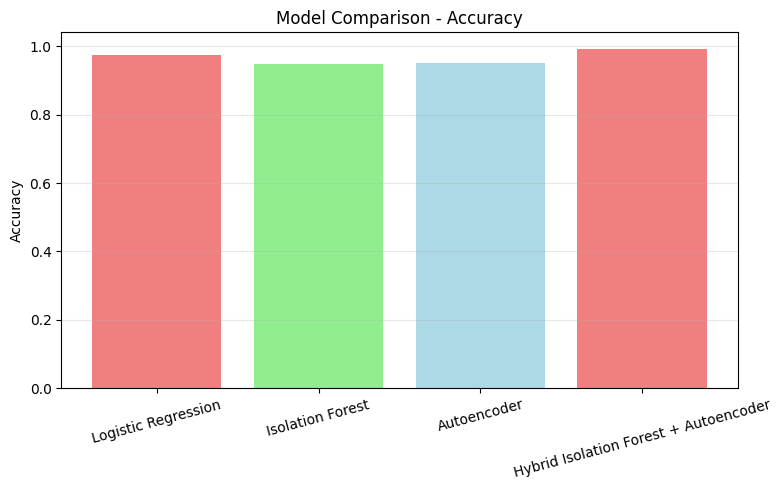

In [82]:
# Accuracy Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"],
    color=["lightcoral", "lightgreen", "lightblue"]
)

plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### **Observation**
The bar chart compares the Accuracy of all evaluated models. Although all models achieve very high Accuracy scores, this metric is not sufficient for evaluating performance on highly imbalanced datasets. Since fraudulent transactions represent only a small fraction of the data, a model can obtain high Accuracy while still failing to detect many fraud cases. Therefore, additional metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC provide a more comprehensive assessment of model performance.

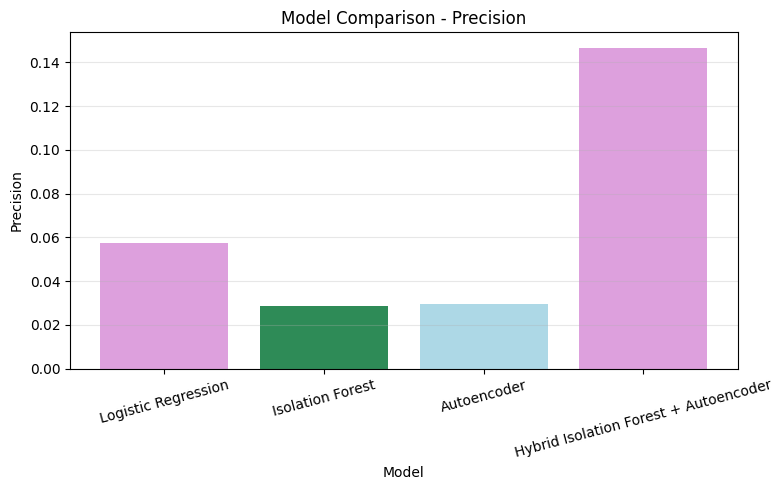

In [83]:
# Precision Comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Precision"],
    color=["plum", "seagreen", "lightblue"]
)

plt.title("Model Comparison - Precision")
plt.xlabel("Model")
plt.ylabel("Precision")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### **Observation**
The chart compares the Precision of all evaluated models. Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent. Higher Precision indicates fewer false positive predictions, reducing unnecessary investigations of legitimate transactions. This metric is particularly important in fraud detection systems, where excessive false alarms can increase operational costs and reduce trust in the model.

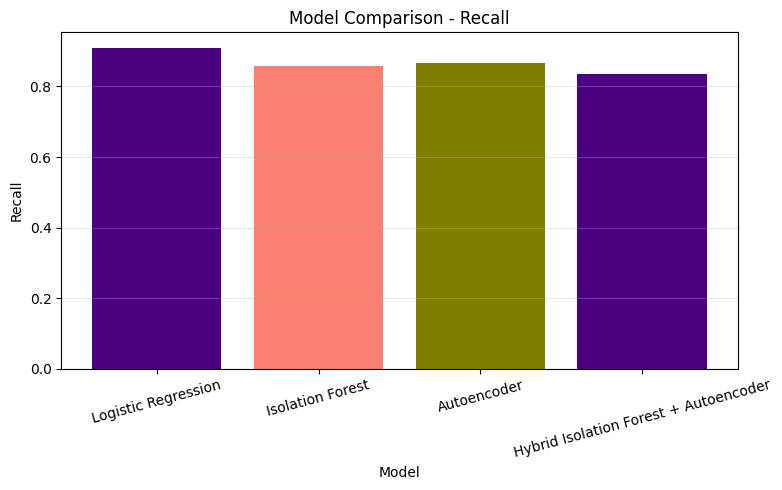

In [84]:
# Recall Comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"],
    color=["indigo", "salmon", "olive"]
)

plt.title("Model Comparison - Recall")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### **Observation**
Recall measures the proportion of actual fraudulent transactions that are correctly identified by each model. A higher Recall indicates that fewer fraud cases are missed, which is essential in fraud detection because undetected fraudulent transactions may result in significant financial losses. Therefore, Recall is one of the most important metrics for evaluating fraud detection models.

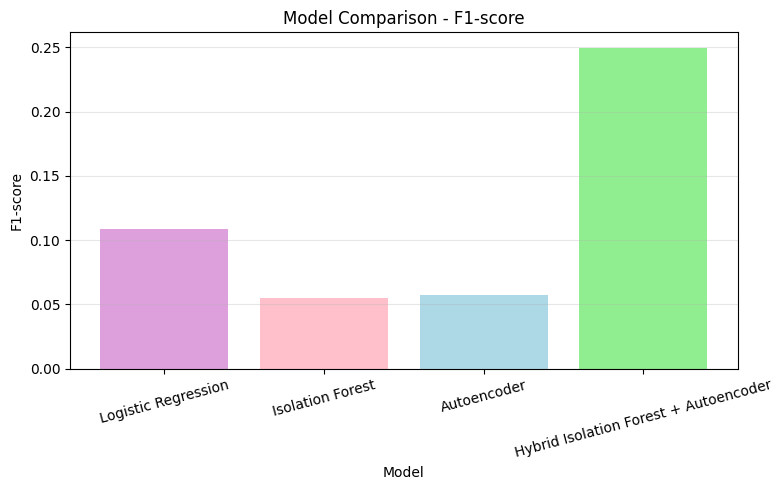

In [86]:
# F1-score Comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1-score"],
    color=["plum", "pink", "lightblue", "lightgreen"]
)

plt.title("Model Comparison - F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### **Observation**
The F1-score is the harmonic mean of Precision and Recall, providing a balanced measure of classification performance. It is particularly useful for highly imbalanced datasets because it considers both the ability to detect fraudulent transactions and the accuracy of fraud predictions. A higher F1-score indicates a better balance between minimizing false positives and false negatives.

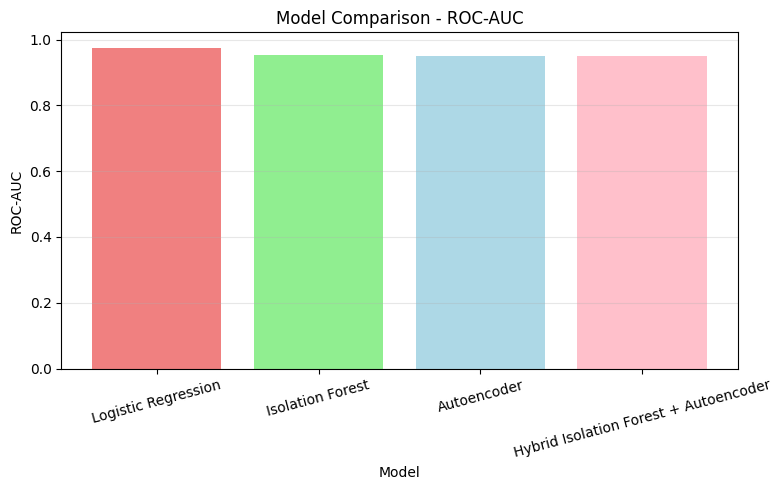

In [88]:
# ROC-AUC Comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"],
    color=["lightcoral", "lightgreen", "lightblue", "pink"]
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### **Observation**
ROC-AUC evaluates a model's ability to distinguish between legitimate and fraudulent transactions across all possible classification thresholds. A higher ROC-AUC indicates better overall discrimination between the two classes. Although ROC-AUC is an important performance metric, it may present an overly optimistic evaluation for highly imbalanced datasets. Therefore, it should be interpreted together with Precision–Recall metrics.

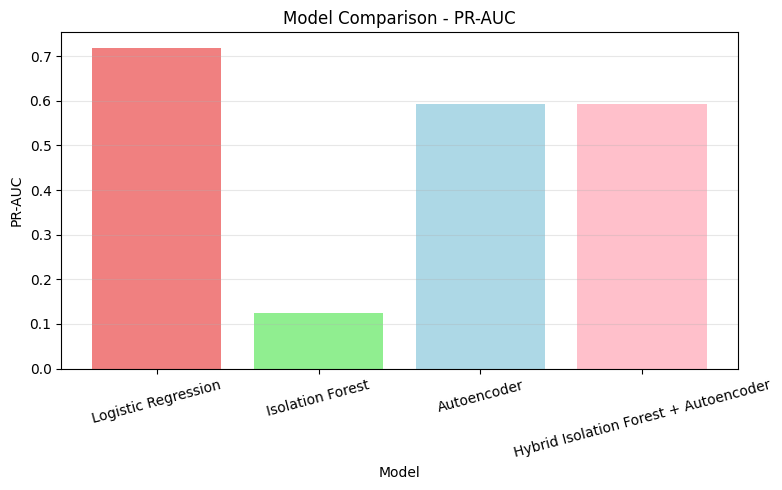

In [ ]:
# PR-AUC Comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["PR-AUC"],
    color=["lightcoral", "lightgreen", "lightblue", "pink"]
)

plt.title("Model Comparison - PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")

plt.xticks(rotation=15)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### **Observation**
The Precision–Recall Area Under the Curve (PR-AUC) is considered the most informative evaluation metric for highly imbalanced classification problems such as credit card fraud detection. Unlike Accuracy and ROC-AUC, PR-AUC focuses specifically on the model's ability to correctly identify the minority class while maintaining high precision. Therefore, PR-AUC is used as the primary metric for comparing model performance and selecting the most effective fraud detection model in this project.

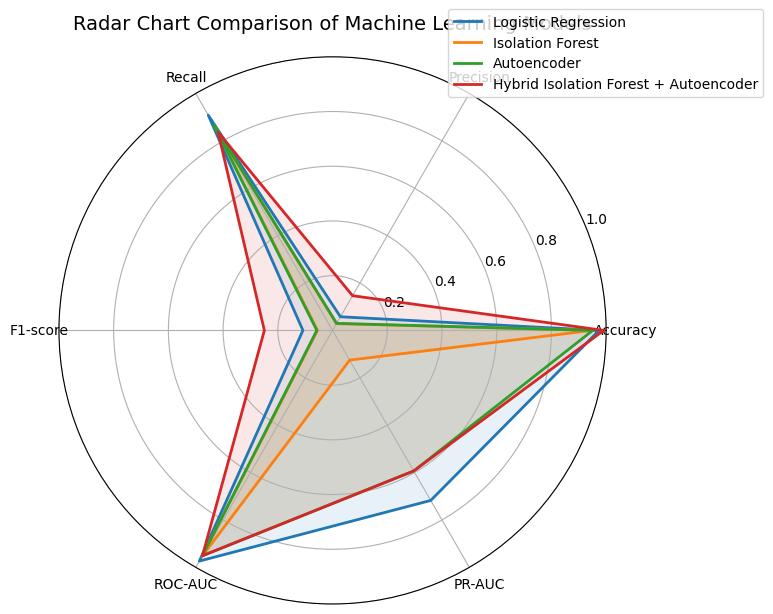

In [90]:
# Radar Chart

# Metrics to display
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]

# Number of variables
num_metrics = len(metrics)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each model
for _, row in comparison_df.iterrows():

    values = [row[m] for m in metrics]
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

# Y-axis
ax.set_ylim(0, 1)

# Title
plt.title(
    "Radar Chart Comparison of Machine Learning Models",
    pad=20,
    fontsize=14
)

# Legend
plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.30, 1.10)
)

plt.tight_layout()

plt.show()

### **Observation**
The radar chart provides a comprehensive visual comparison of all evaluated models across the six performance metrics. Each axis represents one evaluation metric, allowing the overall strengths and weaknesses of every model to be observed simultaneously.

Models with larger and more balanced polygons generally demonstrate stronger and more consistent performance across multiple evaluation criteria. The radar chart complements the individual metric comparisons by providing an overall view of model performance, making it easier to identify the most robust fraud detection model.

## <u>Save Models</u>

In [141]:
# ==========================================================
# Section 21 — Save Trained Models and Parameters
# ==========================================================

import os
import joblib


# ==========================================================
# Create Save Directory
# ==========================================================

os.makedirs(
    "saved_models",
    exist_ok=True
)


# ==========================================================
# 1. Save Logistic Regression
# ==========================================================

joblib.dump(
    lr_model,
    "saved_models/logistic_regression.pkl"
)


# ==========================================================
# 2. Save Isolation Forest
# ==========================================================

joblib.dump(
    iso_forest,
    "saved_models/isolation_forest.pkl"
)


# ==========================================================
# 3. Save Feature Scaler
# ==========================================================

joblib.dump(
    scaler,
    "saved_models/feature_scaler.pkl"
)


# ==========================================================
# 4. Save Autoencoder
# ==========================================================

autoencoder.save(
    "saved_models/autoencoder.keras"
)


# ==========================================================
# 5. Save Isolation Forest Score Scaler
# ==========================================================

joblib.dump(
    iso_score_scaler,
    "saved_models/iso_score_scaler.pkl"
)


# ==========================================================
# 6. Save Autoencoder Score Scaler
# ==========================================================

joblib.dump(
    ae_score_scaler,
    "saved_models/ae_score_scaler.pkl"
)


# ==========================================================
# 7. Save Feature Column Names
# ==========================================================

FEATURE_COLUMNS = X.columns.tolist()

joblib.dump(
    FEATURE_COLUMNS,
    "saved_models/feature_columns.pkl"
)


# ==========================================================
# 8. Save Model Parameters
# ==========================================================

model_parameters = {

    # ------------------------------------------
    # Isolation Forest
    # ------------------------------------------

    "iso_threshold":
        float(iso_threshold),

    # ------------------------------------------
    # Autoencoder
    # ------------------------------------------

    "ae_threshold":
        float(ae_threshold),

    # ------------------------------------------
    # Hybrid Model
    # ------------------------------------------

    "best_iso_weight":
        float(best_iso_weight),

    "best_ae_weight":
        float(best_ae_weight),

    "best_threshold":
        float(best_threshold),

    # ------------------------------------------
    # Optional: Best Validation F1
    # ------------------------------------------

    "best_f1":
        float(best_f1)
}


joblib.dump(
    model_parameters,
    "saved_models/model_parameters.pkl"
)


# ==========================================================
# 9. Display Saved Files
# ==========================================================

print("=" * 60)
print("ALL MODELS SAVED SUCCESSFULLY")
print("=" * 60)

print()

for filename in sorted(
    os.listdir("saved_models")
):

    print(
        f"✓ {filename}"
    )

ALL MODELS SAVED SUCCESSFULLY

✓ ae_score_scaler.pkl
✓ autoencoder.keras
✓ feature_columns.pkl
✓ feature_scaler.pkl
✓ iso_score_scaler.pkl
✓ isolation_forest.pkl
✓ logistic_regression.pkl
✓ model_parameters.pkl
✓ scaler.pkl
